# Lung Dataset Analysis

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from openpyxl import load_workbook
import os

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier  # or any classifier of your choice
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
import shap
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind
from matplotlib.patches import Patch


/home2/poorvi.c/miniconda3/envs/research/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home2/poorvi.c/miniconda3/envs/research/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def read_file(file, index=False):
    file_ext = os.path.splitext(file)[1].lower()
    
    if file_ext == '.xlsx':
        if index:
            data = pd.read_excel(file, index_col=0)
        else:
            data = pd.read_excel(file)
    
    elif file_ext == '.csv':
        if index:
            data = pd.read_csv(file, index_col=0)
        else:
            data = pd.read_csv(file)
    
    elif file_ext == '.txt':
        data = pd.read_csv(file, header=None, names=['Gene'])
        data['Gene'] = data['Gene'].str.strip()
    
    else:
        raise ValueError(f"Unsupported file format: {file_ext}. Supported formats are: .xlsx, .csv, .txt")
    
    return data


In [4]:
# derive the combined_gene_list (combination of all the three way conserved gene lists)
file = "../../results/module_comparison/three_way_module_associations_significant.csv"
associations = read_file(file)
def parse_gene_list(list_string):
    cleaned = list_string.strip('[]').split(', ')
    return [gene.strip().strip("'\"") for gene in cleaned]

associations["genes"] = associations["genes"].apply(parse_gene_list)

combined_gene_list = [gene for gene_list in associations["genes"] for gene in gene_list]
len(combined_gene_list)

172

In [5]:
# process RATs list of genes
rats = pd.read_excel('../../data/rats.xlsx', header=None)
rats.columns = ['gene']
rats = rats['gene'].tolist()
print(len(rats))

def process_rats(rats):
    processed_rats = []
    for gene in rats:
        if gene != '':
            if "///" in str(gene):
                genes = gene.split("///")
                for i in genes:
                    processed_rats.append(i.replace('/', '').replace(' ', ''))
            else:
                processed_rats.append(str(gene).replace('/', '').replace(' ', ''))
    return processed_rats

processed_rats = process_rats(rats)
rats = list(np.unique(processed_rats))
print(len(rats))

454
350


### ML utility functions

In [6]:
# function to produce a subset of the expression matrix given a list of genes
def filter_genes(data, genes):
    genes = [gene for gene in genes if gene in data.columns]
    data = data[genes]
    return data

In [7]:
num_folds = 10
skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

In [8]:
def mean_ci(values, confidence=0.95):
    values = np.array(values)
    mean = np.mean(values)
    se = np.std(values, ddof=1) / np.sqrt(len(values))
    z = 1.96  # 95% CI
    lower = mean - z * se
    upper = mean + z * se
    return mean, lower, upper

In [9]:
def avg_acc_auc(X, y, model_type="rndm"):
    accuracies = []
    aucs = []
    best_auc = 0
    best_model = None

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        if model_type == "rndm":
            clf = RandomForestClassifier(n_estimators=100, random_state=42)
            clf.fit(X_train, y_train)
            
        elif model_type == "svm":
            clf = Pipeline([
                ('scaler', StandardScaler()),
                ('svm', SVC(kernel='linear', C=1.0, probability=True, random_state=42))
            ])
            clf.fit(X_train, y_train)
            
        elif model_type == "lasso":
            clf = Pipeline([
                ('scaler', StandardScaler()),
                ('lasso', LogisticRegression(penalty='l1', C=0.1, solver='liblinear', random_state=42))
            ])
            clf.fit(X_train, y_train)

        if model_type == "rndm":
            y_pred = clf.predict(X_test)
            y_pred_proba = clf.predict_proba(X_test)[:, 1]
        else:
            y_pred = clf.predict(X_test)
            y_pred_proba = clf.predict_proba(X_test)[:, 1]
            
        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        accuracies.append(accuracy)
        aucs.append(auc)

        if auc > best_auc:
            best_auc = auc
            best_model = clf
    
    if model_type == "rndm":
        feature_importance = best_model.feature_importances_
    elif model_type == "svm":
        feature_importance = np.abs(best_model.named_steps['svm'].coef_[0])
    elif model_type == "lasso":
        feature_importance = np.abs(best_model.named_steps['lasso'].coef_[0])

            
    return accuracies, aucs, best_model, feature_importance if best_model is not None else None

def get_train_test_gap(model, X, y):
    train_scores = []
    test_scores = []
    
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        if hasattr(model, 'fit'):
            model.fit(X_train, y_train)
            train_score = model.score(X_train, y_train)
            test_score = model.score(X_test, y_test)
        else:  
            model.fit(X_train, y_train)
            train_score = model.score(X_train, y_train)
            test_score = model.score(X_test, y_test)
            
        train_scores.append(train_score)
        test_scores.append(test_score)
    
    return np.mean(train_scores) - np.mean(test_scores)


def compare_models(data, meta, category, genes_list, models=["rndm", "svm", "lasso"]):
    results = []
    
    for model_type in models:
        X = filter_genes(data, genes_list)
        y = meta[category]
        
        accuracies, aucs, best_model, _ = avg_acc_auc(X, y, model_type)
        
        mean_auc, lower_auc, upper_auc = mean_ci(aucs)
        mean_acc, lower_acc, upper_acc = mean_ci(accuracies)

        results.append({
            'model': model_type,
            'accuracy_mean': mean_acc,
            'accuracy_ci_lower': lower_acc,
            'accuracy_ci_upper': upper_acc,
            'std_acc': np.std(accuracies),
            'std_auc': np.std(aucs),
            'auc_mean': mean_auc,
            'auc_ci_lower': lower_auc,
            'auc_ci_upper': upper_auc,
            'train_test_gap': get_train_test_gap(best_model, X, y) if best_model is not None else None
        })

    return pd.DataFrame(results)

In [10]:
def get_feature_importances(data, meta, category, genes, model_type="lasso"):
    overlap = [gene for gene in genes if gene in data.columns]
    X = filter_genes(data, overlap)
    y = meta[category]
    accuracies, aucs, best_model, feature_importance = avg_acc_auc(X, y, model_type)
    print(np.mean(accuracies), np.mean(aucs))

    builtin_importance = pd.Series(feature_importance, index=X.columns).sort_values(ascending=False)

    perm_imp = permutation_importance(best_model, X, y, n_repeats=10, random_state=42, scoring='roc_auc')
    permutation_importance_scores = pd.Series(perm_imp.importances_mean, index=X.columns).sort_values(ascending=False)

    try:
        if hasattr(best_model, 'named_steps'):
            if 'lasso' in best_model.named_steps:
                model_for_shap = best_model.named_steps['lasso']
                X_scaled = best_model.named_steps['scaler'].transform(X)
                explainer = shap.LinearExplainer(model_for_shap, X_scaled)
                shap_values = explainer.shap_values(X_scaled)
            elif 'svm' in best_model.named_steps:
                model_for_shap = best_model.named_steps['svm']
                X_scaled = best_model.named_steps['scaler'].transform(X)
                explainer = shap.LinearExplainer(model_for_shap, X_scaled)
                shap_values = explainer.shap_values(X_scaled)
        else:
            explainer = shap.TreeExplainer(best_model)
            shap_values = explainer.shap_values(X)
            
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
            elif len(shap_values.shape) == 3:
                shap_values = shap_values[:, :, 1]
                
    except Exception as e:
        print(f"TreeExplainer failed with error: {e}")
        print("Falling back to general Explainer...")
        
        explainer = shap.Explainer(best_model, X)
        shap_values = explainer(X).values
        
        if len(shap_values.shape) == 3:
            shap_values = shap_values[:, :, 1]
        elif len(shap_values.shape) == 2 and shap_values.shape[1] != X.shape[1]:
            if shap_values.shape[1] == 2:
                print(f"Warning: Unexpected SHAP output shape {shap_values.shape}")
                print("SHAP values should have shape (n_samples, n_features)")
                print("Check your model and data setup")
                return None

    if len(shap_values.shape) != 2 or shap_values.shape[1] != X.shape[1]:
        print(f"Error: SHAP values have shape {shap_values.shape}, expected ({X.shape[0]}, {X.shape[1]})")
        return None

    shap_importance_scores = pd.Series(
        np.abs(shap_values).mean(axis=0), 
        index=X.columns
    ).sort_values(ascending=False)
    
    importance_df = pd.DataFrame({
        'builtin': builtin_importance,
        'permutation': permutation_importance_scores,
        'shap': shap_importance_scores
    })

    for col in importance_df.columns:
        importance_df[col] = (importance_df[col] - importance_df[col].min()) / (importance_df[col].max() - importance_df[col].min())

    importance_df['consensus'] = importance_df.mean(axis=1)
    consensus_ranking = importance_df.sort_values('consensus', ascending=False)
    print("Top 10 features by consensus:")
    print(consensus_ranking.head(10))

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    builtin_importance.head(10).plot(kind='barh', ax=axes[0,0], title='Built-in Importance')
    permutation_importance_scores.head(10).plot(kind='barh', ax=axes[0,1], title='Permutation Importance')
    shap_importance_scores.head(10).plot(kind='barh', ax=axes[1,0], title='SHAP Importance')
    consensus_ranking['consensus'].head(10).plot(kind='barh', ax=axes[1,1], title='Consensus Ranking')
    plt.tight_layout()
    plt.show()

    shap.summary_plot(shap_values, X, plot_type="bar", max_display=15)
    shap.summary_plot(shap_values, X, max_display=15)
    return consensus_ranking['consensus']

### Biomarker Validation

In [11]:
data_liver = read_file('../../data/GSE145780_liver.csv', index=True)
meta_liver = read_file('../../data/liver_meta.xlsx', index=True)
data_kidney = read_file("../../data/GSE192444_kidney.csv", index=True)
meta_kidney = read_file('../../data/kidney_meta.xlsx', index=True)
data_heart = read_file("../../data/GSE272655_heart.csv", index=True)
meta_heart = read_file('../../data/heart_meta.xlsx', index=True)

In [12]:
twenty_gene_biomarker = ['KLRD1','FCGR1A','NKG7','CXCL11','CXCL9','PRF1','MSR1',
'EOMES','APOL3','SAMD3','IRF8','GBP1','HLA-F','RUNX3','STAT1','TRAF5','CSF2RA',
'CCL5','HCP5','ENTPD1']

six_gene_biomarker = ['KLRD1','FCGR1A','NKG7','CXCL11','CXCL9','PRF1']

cell_cycle_genes = ['ANLN','ASPM','BUB1','BUB1B','CCNA2','CCNB1','CDKN3','CENPA','CENPF','CEP55','DLGAP5','DTL','EZH2','KIAA0101','KIF11','KIF20A','MKI67','NUSAP1','RRM2','TOP2A','TPX2','TTK','TYMS','UBE2C']

#### 20 gene biomarker performance on organs (liver, kidney, heart)

In [96]:
compare_models(data_liver, meta_liver, "classes", twenty_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.932428,0.897273,0.967582,0.053808,0.015674,0.989371,0.979130,0.999611,0.067572
1,svm,0.885145,0.845850,0.924440,0.060145,0.032946,0.962331,0.940807,0.983855,0.049128
2,lasso,0.863587,0.817273,0.909901,0.070889,0.036355,0.944744,0.920992,0.968495,0.021515


In [97]:
compare_models(data_kidney, meta_kidney, "group", twenty_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.910000,0.886044,0.933956,0.036667,0.043708,0.955216,0.926660,0.983772,0.090000
1,svm,0.946667,0.922416,0.970917,0.037118,0.038431,0.971652,0.946544,0.996761,0.020370
2,lasso,0.920000,0.884615,0.955385,0.054160,0.036896,0.959825,0.935719,0.983930,0.000741


In [98]:
compare_models(data_heart, meta_heart, "group", twenty_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.956593,0.925404,0.987783,0.047739,0.046069,0.965972,0.935874,0.996071,0.043407
1,svm,0.890659,0.859264,0.922055,0.048054,0.049749,0.955000,0.922497,0.987503,0.068789
2,lasso,0.920330,0.876357,0.964302,0.067305,0.040346,0.967222,0.940863,0.993581,0.013174


#### 6 gene biomarker performance on organs (liver, kidney, heart)

In [99]:
compare_models(data_liver, meta_liver, "classes", six_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.923188,0.898885,0.947492,0.037199,0.033885,0.954202,0.932063,0.976340,0.076812
1,svm,0.884420,0.837265,0.931576,0.072177,0.055049,0.937622,0.901657,0.973588,0.009179
2,lasso,0.841486,0.780293,0.902678,0.093662,0.049328,0.938380,0.906153,0.970607,0.013345


In [100]:
compare_models(data_kidney, meta_kidney, "group", six_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.900000,0.866262,0.933738,0.051640,0.046523,0.958357,0.927962,0.988753,0.100000
1,svm,0.910000,0.877625,0.942375,0.049554,0.031160,0.964813,0.944455,0.985170,0.015556
2,lasso,0.906667,0.865576,0.947757,0.062893,0.037127,0.960751,0.936494,0.985007,0.008148


In [101]:
compare_models(data_heart, meta_heart, "group", six_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.913187,0.872643,0.953730,0.062056,0.050389,0.968750,0.935829,1.001671,0.086813
1,svm,0.920330,0.881625,0.959034,0.059241,0.042040,0.959722,0.932256,0.987188,0.004244
2,lasso,0.920330,0.876357,0.964302,0.067305,0.040620,0.962222,0.935684,0.988761,0.005057


## External Validation on the Lung Dataset

In [89]:
data_lung = read_file("../../data/GSE125004_lung.csv", index=True)
meta_lung = read_file("../../data/GSE125004_sample_info.csv", index=True)

In [90]:
data_lung.index = meta_lung.index
data_lung

,HIST1H3G,TNFAIP8L1,OTOP2,C17orf78,LOC285501,SAMD7,ARRDC5,C1orf173,FAM86C,HIST1H2BI,...,Empty_114,Empty_115,Empty_116,Empty_117,Empty_118,Empty_119,Empty_120,Empty_121,Empty_122,Empty_123
GSM4046057,4.67325,9.1495,5.8190,3.470,3.1820,3.470,5.699,11.150,7.853000,3.128333,...,2.841,3.138,3.144,3.105,3.541,3.321,2.719,3.142,2.933,3.555
GSM4046058,4.75125,8.9950,5.7275,3.403,3.5375,3.662,5.809,11.008,8.209667,3.413333,...,2.807,3.273,3.320,3.283,3.506,3.434,2.898,3.086,2.983,3.454
GSM4046059,4.64775,8.3780,6.0645,3.546,3.4965,3.814,5.823,10.206,7.864667,3.159000,...,3.017,3.233,3.189,3.226,3.480,3.376,2.820,3.175,3.036,3.550
GSM4046060,4.74650,8.0035,6.0695,3.414,3.3935,3.694,5.728,9.362,7.764000,3.174000,...,2.896,3.125,3.153,3.203,3.533,3.328,2.712,3.372,3.064,3.573
GSM4046061,5.06200,8.6635,6.2345,3.580,3.7535,3.626,6.167,9.882,8.103333,3.248000,...,2.937,3.323,3.447,3.148,3.718,3.503,2.790,3.323,3.026,3.948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM4046295,4.70850,7.4345,5.8720,3.590,3.4960,3.503,5.857,8.616,7.762000,3.143667,...,2.877,3.362,3.280,3.111,3.557,3.592,2.821,3.091,3.021,3.646
GSM4046296,4.92000,8.9680,6.1975,3.535,3.5075,3.595,6.028,10.813,8.374333,3.214333,...,2.948,3.228,3.289,3.262,3.642,3.661,2.820,3.250,3.094,3.887
GSM4046297,4.95125,8.5735,6.1200,3.636,3.6525,3.744,6.138,10.228,8.188667,3.327333,...,2.898,3.376,3.560,3.276,3.590,3.602,2.842,3.154,3.107,3.841
GSM4046298,4.87325,7.7670,5.8900,3.410,3.4890,3.425,6.148,8.896,7.950667,2.976333,...,2.941,3.303,3.320,3.083,3.643,3.549,2.797,3.131,3.042,3.838


In [91]:
meta_lung['group'] = np.where(meta_lung['cluster (1, 2, 3, 4):ch1'] != '1', 'treatment', 'control')

In [92]:
overlap = [gene for gene in rats if gene in data_lung.columns]
print(len(overlap))

304


In [106]:
# rats performance
compare_models(data_lung, meta_lung, "group", overlap)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.934000,0.903639,0.964361,0.046471,0.017615,0.989072,0.977564,1.000581,0.066000
1,svm,0.930333,0.896554,0.964113,0.051703,0.021090,0.976766,0.962987,0.990545,0.069667
2,lasso,0.954833,0.926571,0.983096,0.043259,0.024166,0.985970,0.970182,1.001759,0.017734


In [107]:
# individual 3 way module performance
for i in range(1,7):
    file = f"../../results/module_comparison/three_way_conserved_genes_{i}.txt"
    gene_list = list(read_file(file)['Gene'])
    print(f"3 way combination {i}")
    three_way_performance = compare_models(data_lung, meta_lung, "group", gene_list)
    print(three_way_performance)
    print("\n")

3 way combination 1
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.946333           0.921720           0.970947  0.037674   
1    svm       0.934667           0.893468           0.975866  0.063060   
2  lasso       0.946167           0.916160           0.976174  0.045929   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.044658  0.977731      0.948554      1.006908        0.053667  
1  0.022939  0.983272      0.968285      0.998259        0.049787  
2  0.024133  0.984185      0.968418      0.999951        0.006278  


3 way combination 2
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.925667           0.893800           0.957533  0.048775   
1    svm       0.926167           0.900408           0.951926  0.039427   
2  lasso       0.934333           0.907023           0.961643  0.041801   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.038962  0.9

In [108]:
for i in range(1,4):
    file = f"../../results/module_comparison/conserved_group_{i}_genes.txt"
    gene_list = list(read_file(file)['Gene'])
    print(f"combination network {i}")
    two_way_performance = compare_models(data_lung, meta_lung, "group", gene_list)
    print(two_way_performance)
    print("\n")

combination network 1
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.925833           0.896501           0.955166  0.044896   
1    svm       0.946500           0.929191           0.963809  0.026494   
2  lasso       0.958833           0.934720           0.982947  0.036909   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.018491  0.989440      0.977359      1.001521        0.074167  
1  0.011458  0.986889      0.979403      0.994375        0.053500  
2  0.025385  0.985924      0.969339      1.002510        0.013730  


combination network 2
   model  accuracy_mean  accuracy_ci_lower  accuracy_ci_upper   std_acc  \
0   rndm       0.678667           0.631209           0.726125  0.072640   
1    svm       0.728000           0.681836           0.774164  0.070659   
2  lasso       0.694667           0.652025           0.737308  0.065268   

    std_auc  auc_mean  auc_ci_lower  auc_ci_upper  train_test_gap  
0  0.095769 

In [109]:
# combined 3 way modules' performance
compare_models(data_lung, meta_lung, "group", combined_gene_list)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.925667,0.898852,0.952482,0.041043,0.016504,0.990221,0.979439,1.001004,0.074333
1,svm,0.950667,0.924118,0.977215,0.040635,0.008849,0.993934,0.988153,0.999715,0.049333
2,lasso,0.959000,0.932203,0.985797,0.041016,0.021308,0.987487,0.973566,1.001408,0.007621


In [110]:
compare_models(data_lung, meta_lung, "group", twenty_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.909333,0.885676,0.932991,0.036211,0.031896,0.966725,0.945886,0.987563,0.090667
1,svm,0.905167,0.877596,0.932737,0.042200,0.024695,0.974875,0.958741,0.991009,0.053687
2,lasso,0.921667,0.902513,0.940820,0.029316,0.034004,0.970864,0.948648,0.993080,0.017062


In [111]:
compare_models(data_lung, meta_lung, "group", six_gene_biomarker)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.863833,0.831797,0.895870,0.049035,0.040771,0.919167,0.892530,0.945804,0.136167
1,svm,0.888500,0.861306,0.915694,0.041623,0.037352,0.938833,0.914429,0.963236,0.009527
2,lasso,0.876333,0.840262,0.912404,0.055211,0.042946,0.935485,0.907427,0.963542,0.006606


In [112]:
compare_models(data_lung, meta_lung, "group", cell_cycle_genes)

,model,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,std_acc,std_auc,auc_mean,auc_ci_lower,auc_ci_upper,train_test_gap
0,rndm,0.678667,0.631209,0.726125,0.072640,0.095769,0.735586,0.673017,0.798155,0.321333
1,svm,0.728000,0.681836,0.774164,0.070659,0.121770,0.745628,0.666072,0.825184,0.059368
2,lasso,0.694667,0.652025,0.737308,0.065268,0.120349,0.728736,0.650108,0.807363,0.000334


### Lung Heatmap

###### Best practice in statistics: Use the Welch t-test when testing the difference between two groups (https://pubmed.ncbi.nlm.nih.gov/33562996/)

In [93]:
def compute_module_eigengene(data, genes):

    genes = [g for g in genes if g in data.columns]
    X = data[genes].copy()

    # Z-score genes (column-wise)
    X_scaled = (X - X.mean()) / X.std()

    pca = PCA(n_components=1)
    eigengene = pca.fit_transform(X_scaled)

    eigengene_series = pd.Series(
        eigengene.flatten(),
        index=X.index,
        name="Module_Eigengene"
    )

    return eigengene_series


In [94]:
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap, to_rgb

def plot_module_heatmap(data, meta, genes, tissue, gene_set, group_col="group"):
    
    genes = [g for g in genes if g in data.columns]
    X = data[genes].copy()
    
    meta_sorted = meta.loc[X.index].sort_values(group_col)
    X = X.loc[meta_sorted.index]
    
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
    X_scaled = X_scaled.T
    
    groups = meta_sorted[group_col]
    unique_groups = groups.unique()
    
    if len(unique_groups) == 2:
        group_color_map = {
            unique_groups[0]: '#4169E1',
            unique_groups[1]: '#DC143C'
        }
    else:
        palette = sns.color_palette("Set2", len(unique_groups))
        group_color_map = dict(zip(unique_groups, palette))
    
    col_colors = groups.map(group_color_map)
    
    sns.set_style("white")
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
    
    fig = plt.figure(figsize=(10, 7))
    gs = GridSpec(
        3, 3,
        width_ratios=[0.8, 18, 3],
        height_ratios=[0.3, 0.25, 10],
        hspace=0.05,
        wspace=0.1,
        left=0.08,
        right=0.97,
        top=0.93,
        bottom=0.08
    )
    
    fig.suptitle("Module Gene Expression Heatmap",
                 fontsize=15, y=0.96)
    
    cbar_ax = fig.add_subplot(gs[2, 0])
    
    ax_bar = fig.add_subplot(gs[1, 1])
    # Convert colors to RGB tuples
    if isinstance(list(group_color_map.values())[0], str):
        color_array = np.array([[to_rgb(c) for c in col_colors]])
    else:
        color_array = np.array([col_colors.tolist()])
    ax_bar.imshow(color_array, aspect="auto", interpolation='nearest')
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])
    ax_bar.set_frame_on(False)
    
    ax = fig.add_subplot(gs[2, 1])
    
    colors_cmap = ['#3A5FCD', '#6A9FE8', '#B3D9FF', '#FFFFFF', 
                   '#FFB3B3', '#FF6B6B', '#E63946']
    cmap = LinearSegmentedColormap.from_list('custom_diverging', colors_cmap, N=100)
    
    hm = ax.imshow(
        X_scaled,
        cmap=cmap,
        aspect='auto',
        interpolation='nearest',
        vmin=-3,
        vmax=3
    )
    
    ax.set_yticks(np.arange(len(genes)))
    ax.set_yticklabels(genes, fontsize=10, fontweight='normal')
    ax.tick_params(axis='y', labelsize=10, length=3, pad=5, left=False, right=True, labelright=True, labelleft=False)
    
    ax.set_xticks([])
    ax.set_xlabel("Samples", fontsize=12, labelpad=8)
    ax.set_ylabel("Genes", fontsize=12, labelpad=10)
    ax.yaxis.set_label_position('right')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(False)
    ax.spines['bottom'].set_linewidth(False)
    
    group_counts = groups.value_counts(sort=False)
    split_positions = np.cumsum(group_counts.values)
    for pos in split_positions[:-1]:
        ax.axvline(pos - 0.5, color='black', linewidth=1.5, linestyle='-')
    
    plt.colorbar(hm, cax=cbar_ax)
    cbar_ax.set_ylabel("Z-score", fontsize=11, labelpad=12)
    cbar_ax.tick_params(labelsize=9, length=4, width=1)
    cbar_ax.yaxis.set_label_position('left')
    cbar_ax.yaxis.tick_left()
    
    legend_ax = fig.add_subplot(gs[2, 2])
    legend_ax.axis("off")
    legend_handles = [
        Patch(facecolor=group_color_map[g], label=g, edgecolor='black', linewidth=0.5)
        for g in unique_groups
    ]
    legend = legend_ax.legend(
        handles=legend_handles,
        title="Group",
        loc="upper left",
        frameon=True,
        fontsize=11,
        title_fontsize=12,
        fancybox=False,
        bbox_to_anchor=(0.2, 1.2)
    )
    
    # Save figure
    save_dir = f"../../figures/{tissue}/{gene_set}"
    os.makedirs(save_dir, exist_ok=True)
    save_path = f"{save_dir}/heatmap.png"
    plt.savefig(save_path, dpi=900, bbox_inches='tight')
    print(f"Saved heatmap to: {save_path}")

    plt.show()

In [95]:
def module_eigengene_ttest(eigengene, meta, group_col="group"):

    groups = meta[group_col]
    unique_groups = groups.unique()

    g1 = eigengene[groups == unique_groups[0]]
    g2 = eigengene[groups == unique_groups[1]]

    t_stat, p_value = ttest_ind(g1, g2, equal_var=False)

    print("==== Welch’s t-test on Module Eigengene ====")
    print(f"{unique_groups[0]} mean = {g1.mean():.3f}")
    print(f"{unique_groups[1]} mean = {g2.mean():.3f}")
    print(f"T-statistic = {t_stat:.3f}")
    print(f"P-value = {p_value:.3e}")

    return t_stat, p_value


In [96]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from pingouin import welch_anova  

def module_eigengene_multi_test(eigengene, meta, group_col="group"):
    
    df = pd.DataFrame({
        "eigengene": eigengene,
        "group": meta[group_col].values
    })

    print("==== Global Welch ANOVA ====")
    anova_res = welch_anova(dv='eigengene', between='group', data=df)
    print(anova_res)
    
    print("\n==== Pairwise Welch t-tests (Holm corrected) ====")
    
    groups = df["group"].unique()
    results = []
    
    for g1, g2 in itertools.combinations(groups, 2):
        x1 = df[df["group"] == g1]["eigengene"]
        x2 = df[df["group"] == g2]["eigengene"]
        
        t_stat, p_val = ttest_ind(x1, x2, equal_var=False)
        
        results.append({
            "Group1": g1,
            "Group2": g2,
            "Mean1": x1.mean(),
            "Mean2": x2.mean(),
            "T-stat": t_stat,
            "P-uncorrected": p_val
        })
    
    results_df = pd.DataFrame(results)
    
    # Multiple testing correction
    corrected = multipletests(results_df["P-uncorrected"], method="holm")
    results_df["P-corrected"] = corrected[1]
    
    print(results_df)
    
    return results_df

In [97]:
def plot_eigengene_boxplot(eigengene, meta, tissue, gene_set, group_col="group"):
    # Define your muted palette
    muted_palette = ['#94bfe0', '#faab96']

    df = pd.DataFrame({
        "Eigengene": eigengene,
        "Group": meta[group_col]
    })

    # Set the style to whitegrid for automatic grid lines
    sns.set_style("whitegrid")

    plt.figure(figsize=(6, 7))
    
    # Draw the boxplot
    ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6) 

    # Draw the stripplot
    sns.stripplot(data=df, x="Group", y="Eigengene", color="black", alpha=0.3)

    # Optional: Customize the grid to be more subtle (dotted/lighter)
    ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.5)
    ax.set_axisbelow(True) # Ensure grid is behind the boxes

    plt.title(f"Module Eigengene ({tissue.capitalize()})")
    plt.ylabel("Module Eigengene (PC1)")
    plt.xlabel("Group")
    plt.tight_layout()

    # Save figure
    save_dir = f"../../figures/{tissue}/{gene_set}"
    os.makedirs(save_dir, exist_ok=True)
    save_path = f"{save_dir}/eigengene_boxplot.png"
    plt.savefig(save_path, dpi=900, bbox_inches='tight')
    print(f"Saved boxplot to: {save_path}")

    plt.show()
    
    # Reset style to default for other plots if needed
    sns.set_style("white")

In [109]:
def plot_multi_group_boxplot(eigengene, meta, tissue, gene_set, group_col="group"):
    color_map = {
        "Normal": "#94bfe0",         # Blue
        "T_cell_injury": "#faab96",   # Salmon/Orange
        "inflammatory_injury": "#caf5b8", # Muted Green
        "rejection": "#f7abd0"        # Muted Purple
    }

    df = pd.DataFrame({
        "Eigengene": eigengene,
        "Group": meta[group_col]
    })

    # Ensure groups appear in a logical biological order
    group_order = ["Normal", "T_cell_injury", "inflammatory_injury", "rejection"]
    # Filter order to only include groups present in the data
    existing_order = [g for g in group_order if g in df["Group"].unique()]

    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 7)) # Increased width for more groups
    
    # Use 'palette=color_map' and 'order=existing_order'
    ax = sns.boxplot(
        data=df, 
        x="Group", 
        y="Eigengene", 
        palette=color_map, 
        order=existing_order,
        width=0.6
    ) 

    sns.stripplot(
        data=df, 
        x="Group", 
        y="Eigengene", 
        order=existing_order, 
        color="black", 
        alpha=0.3,
        size=4 # Smaller dots if sample size is high
    )

    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

    plt.title(f"Module Eigengene (Lung)")
    plt.ylabel("Module Eigengene (PC1)")
    # plt.xticks(rotation=45) # Rotate labels if they overlap
    plt.tight_layout()

    # Save figure
    save_dir = f"../../figures/{tissue}/{gene_set}"
    os.makedirs(save_dir, exist_ok=True)
    save_path = f"{save_dir}/eigengene_multi_boxplot.png"
    plt.savefig(save_path, dpi=900, bbox_inches='tight')
    print(f"Saved boxplot to: {save_path}")

    plt.show()

    sns.set_style("white")

In [110]:
def plot_eigengene_bar(eigengene, meta, tissue, gene_set, module_name="Module",
                       group_col="group"):

    df = pd.DataFrame({
        "Eigengene": eigengene,
        "Group": meta[group_col]
    })

    # Sort by group
    df = df.sort_values("Group").reset_index(drop=True)

    unique_groups = df["Group"].unique()

    if len(unique_groups) == 2:
        group_color_map = {
            unique_groups[0]: '#4169E1',
            unique_groups[1]: '#DC143C'
        }
    else:
        palette = sns.color_palette("Set2", len(unique_groups))
        group_color_map = dict(zip(unique_groups, palette))
    
    # col_colors = groups.map(group_color_map)

    # colors = plt.cm.Set1.colors
    # group_color_map = dict(zip(unique_groups, colors[:len(unique_groups)]))

    bar_colors = df["Group"].map(group_color_map)

    plt.figure(figsize=(14,6))

    plt.bar(
        range(len(df)),
        df["Eigengene"],
        color=bar_colors,
        width=1.0
    )

    plt.axhline(0, color='black', linewidth=1)

    legend_elements = [
        Patch(facecolor=group_color_map[g], label=g)
        for g in unique_groups
    ]

    plt.legend(handles=legend_elements, title="Cluster",
               bbox_to_anchor=(1, 1), loc="upper left")

    plt.title(f"Eigengene Expression ({module_name})", fontsize=13)
    plt.ylabel("Eigengene expression", fontsize = 12)
    plt.xlabel("Samples", fontsize=12)

    plt.xticks([])  # Hide sample ticks
    plt.tight_layout()

    # Save figure
    save_dir = f"../../figures/{tissue}/{gene_set}"
    os.makedirs(save_dir, exist_ok=True)
    save_path = f"{save_dir}/eigengene_barplot.png"
    plt.savefig(save_path, dpi=900, bbox_inches='tight')
    print(f"Saved barplot to: {save_path}")

    plt.show()


#### Lung

Saved heatmap to: ../../figures/lung/20 gene biomarker/heatmap.png


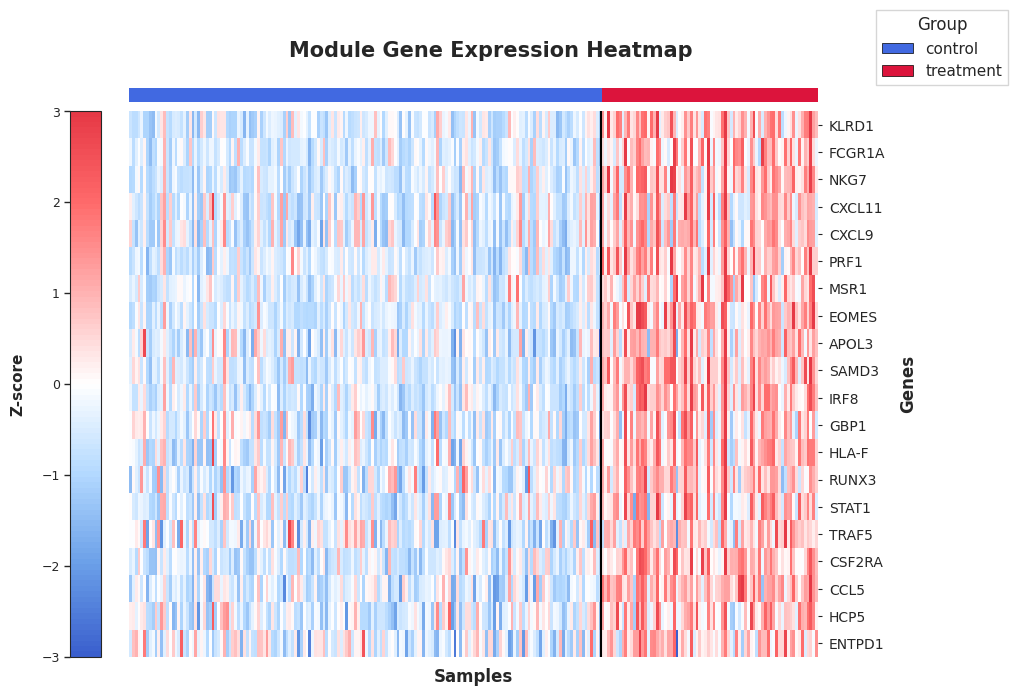

==== Welch’s t-test on Module Eigengene ====
control mean = -1.742
treatment mean = 3.806
T-statistic = -14.351
P-value = 2.661e-26


/tmp/ipykernel_2159828/561073009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)


Saved boxplot to: ../../figures/lung/20 gene biomarker/eigengene_boxplot.png


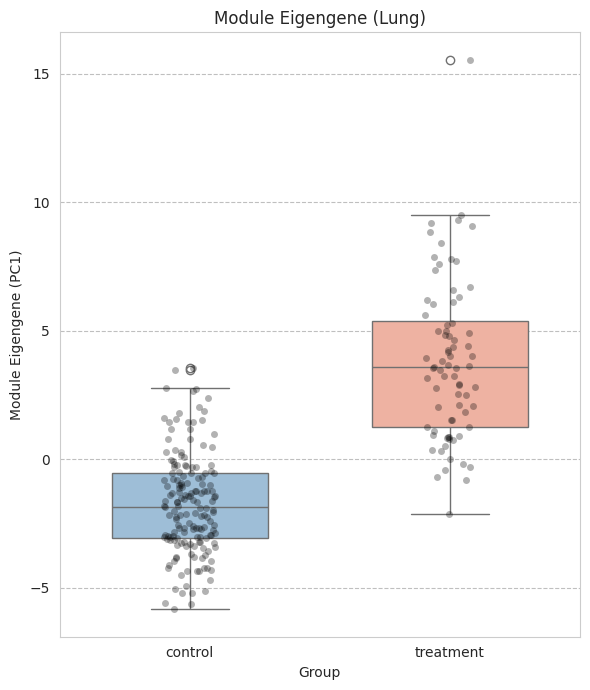

Saved barplot to: ../../figures/lung/20 gene biomarker/eigengene_barplot.png


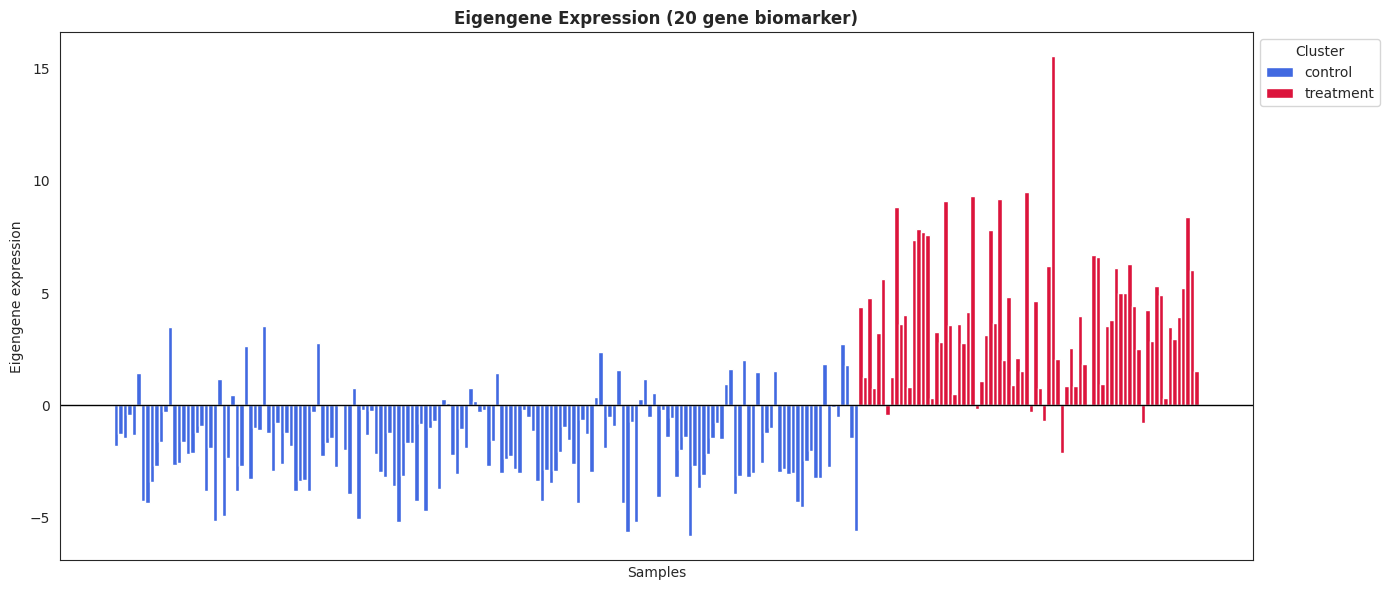

In [69]:
# 1 Heatmap
plot_module_heatmap(data_lung, meta_lung, twenty_gene_biomarker, 'lung', '20 gene biomarker')

# 2 Compute eigengene
eigengene_lung = compute_module_eigengene(data_lung, twenty_gene_biomarker)

# 3 Welch test
module_eigengene_ttest(eigengene_lung, meta_lung)

# 4 Plot eigengene distribution
plot_eigengene_boxplot(eigengene_lung, meta_lung, 'lung', '20 gene biomarker')

# 5 Plot eigengene bar plot
plot_eigengene_bar(eigengene_lung, meta_lung, 'lung', '20 gene biomarker',
                   module_name="20 gene biomarker")


Saved heatmap to: ../../figures/lung/6 gene biomarker/heatmap.png


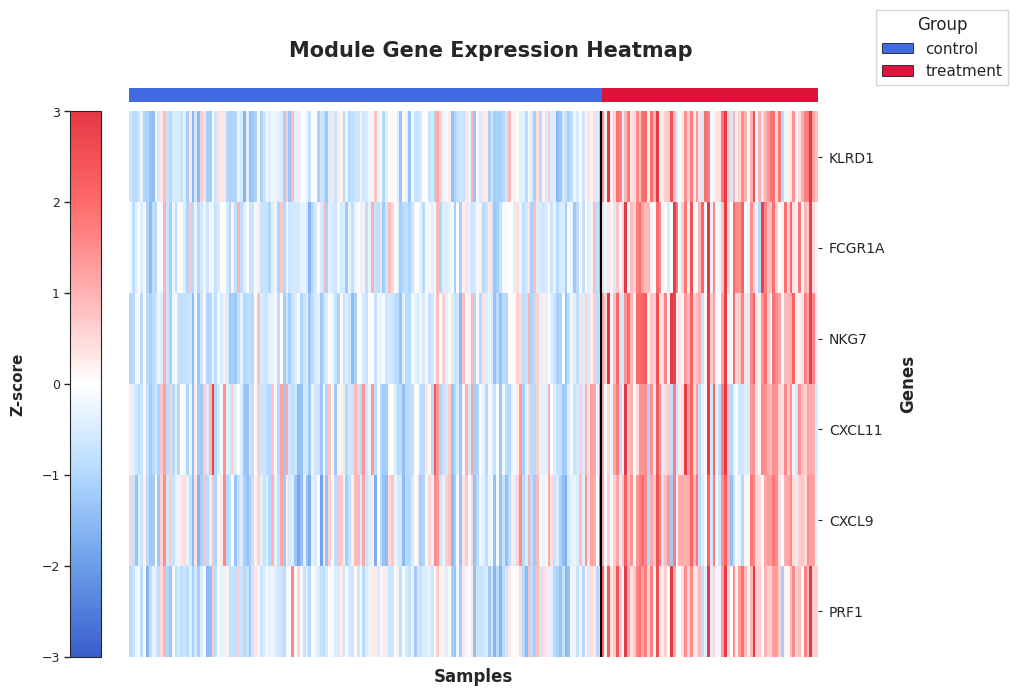

==== Welch’s t-test on Module Eigengene ====
control mean = -0.989
treatment mean = 2.159
T-statistic = -12.714
P-value = 9.623e-23


/tmp/ipykernel_2159828/561073009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)


Saved boxplot to: ../../figures/lung/6 gene biomarker/eigengene_boxplot.png


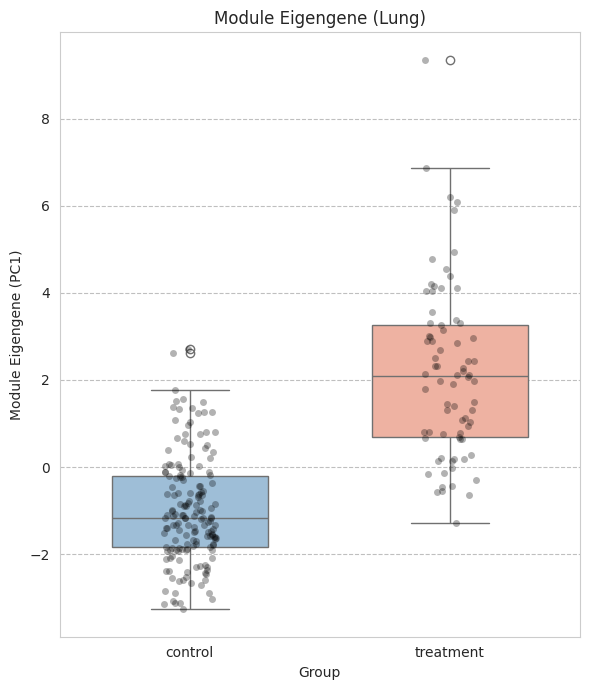

Saved barplot to: ../../figures/lung/6 gene biomarker/eigengene_barplot.png


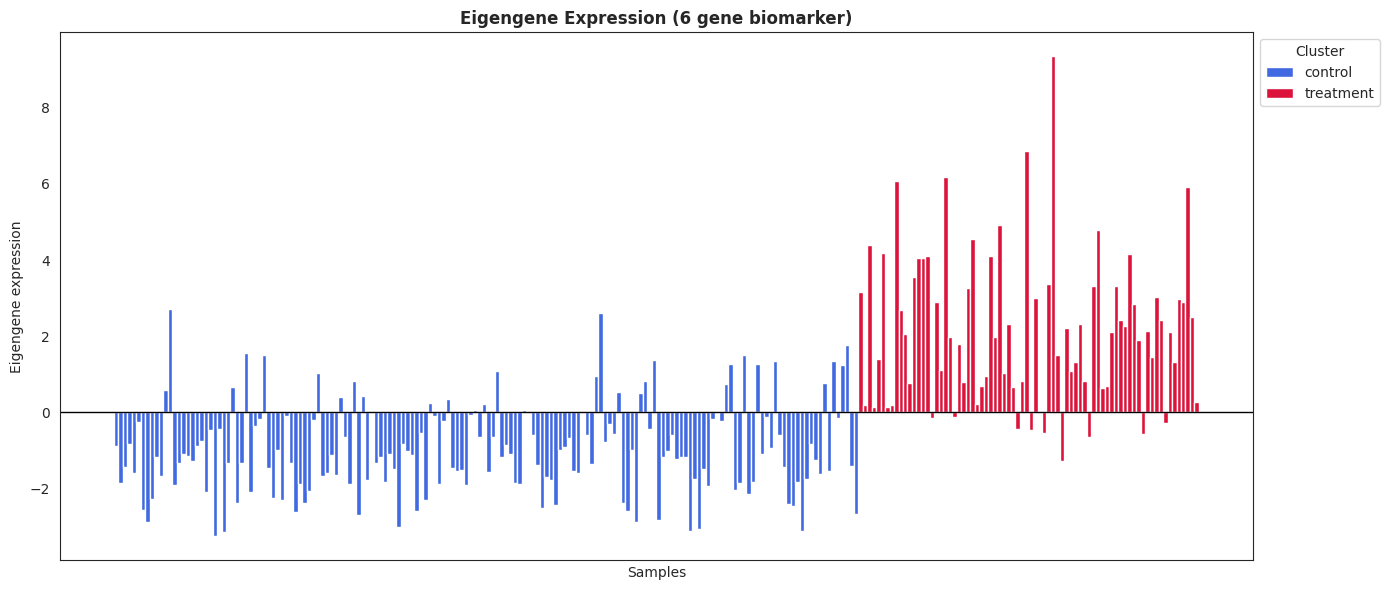

In [70]:
# 1 Heatmap
plot_module_heatmap(data_lung, meta_lung, six_gene_biomarker, 'lung', '6 gene biomarker')

# 2 Compute eigengene
eigengene_lung = compute_module_eigengene(data_lung, six_gene_biomarker)

# 3 Welch test
module_eigengene_ttest(eigengene_lung, meta_lung)

# 4 Plot eigengene distribution
plot_eigengene_boxplot(eigengene_lung, meta_lung, 'lung', '6 gene biomarker')

# 5 Plot eigengene bar plot
plot_eigengene_bar(eigengene_lung, meta_lung, 'lung', '6 gene biomarker',
                   module_name="6 gene biomarker")

In [100]:
# Find rows in meta_lung where 'cluster (1, 2, 3, 4):ch1' is 'N/A'
valid_mask = meta_lung['cluster (1, 2, 3, 4):ch1'] != '#N/A!'

# Filter both dataframes using the same mask
meta_lung = meta_lung[valid_mask]
data_lung = data_lung[valid_mask]

# Verify
print(f"Shape after filtering: {data_lung.shape}")
print(meta_lung['cluster (1, 2, 3, 4):ch1'].value_counts())

Shape after filtering: (242, 19730)
cluster (1, 2, 3, 4):ch1
1    166
3     36
2     24
4     16
Name: count, dtype: int64


In [101]:
# 1 - Lack of inflammation, rejection, and injury, 
# 2 - IFNG effects (rejection) 
# 3 - T cell and inflammatory infiltrate (late injury/late), 
# 4 - Recent injury: inflammation and innate immune response

meta_lung['cluster (1, 2, 3, 4):ch1'] = meta_lung['cluster (1, 2, 3, 4):ch1'].replace({
    '1': 'Normal',
    '2': 'rejection',
    '3': 'T_cell_injury',
    '4': 'inflammatory_injury'
})

# Verify the replacement
print(meta_lung['cluster (1, 2, 3, 4):ch1'].value_counts())

cluster (1, 2, 3, 4):ch1
Normal                 166
T_cell_injury           36
rejection               24
inflammatory_injury     16
Name: count, dtype: int64


Saved heatmap to: ../../figures/lung_all/20 gene biomarker/heatmap.png


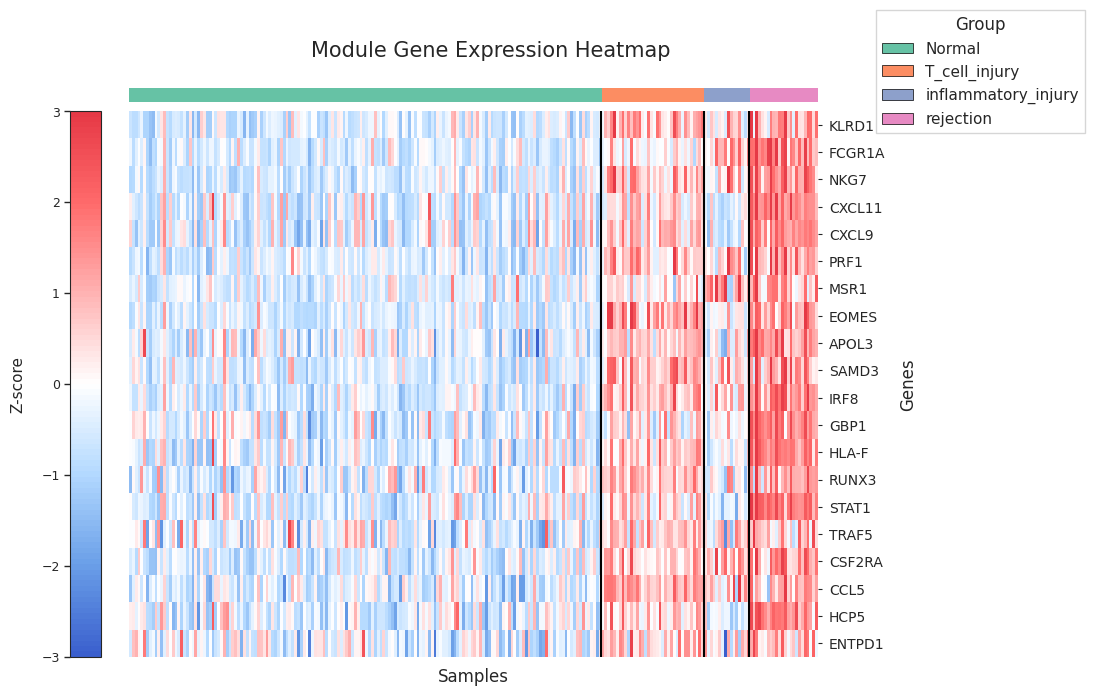

==== Global Welch ANOVA ====
  Source  ddof1     ddof2           F         p-unc       np2
0  group      3  42.98751  105.503176  7.497111e-20  0.650817

==== Pairwise Welch t-tests (Holm corrected) ====
          Group1               Group2     Mean1     Mean2     T-stat  \
0         Normal        T_cell_injury -1.742353  3.194971 -12.078356   
1         Normal            rejection -1.742353  6.554055 -13.933093   
2         Normal  inflammatory_injury -1.742353  1.057148  -6.324386   
3  T_cell_injury            rejection  3.194971  6.554055  -4.868189   
4  T_cell_injury  inflammatory_injury  3.194971  1.057148   3.794056   
5      rejection  inflammatory_injury  6.554055  1.057148   7.735574   

   P-uncorrected   P-corrected  
0   5.747253e-16  3.448352e-15  
1   1.219325e-13  6.096624e-13  
2   4.351765e-06  1.305529e-05  
3   1.621769e-05  3.243538e-05  
4   5.060945e-04  5.060945e-04  
5   2.739800e-09  1.095920e-08  


/tmp/ipykernel_2159828/561073009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)
/tmp/ipykernel_2159828/561073009.py:16: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)


Saved boxplot to: ../../figures/lung_all/20 gene biomarker/eigengene_boxplot.png


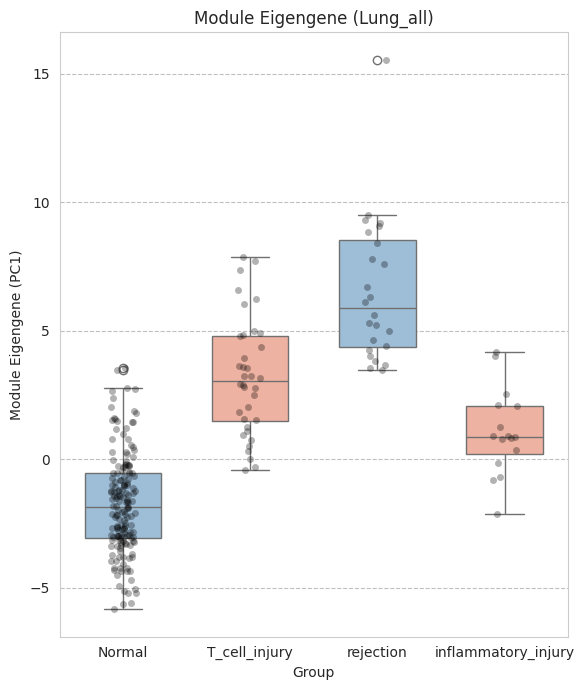

/tmp/ipykernel_2159828/2373337035.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


Saved boxplot to: ../../figures/lung_all/20 gene biomarker/eigengene_multi_boxplot.png


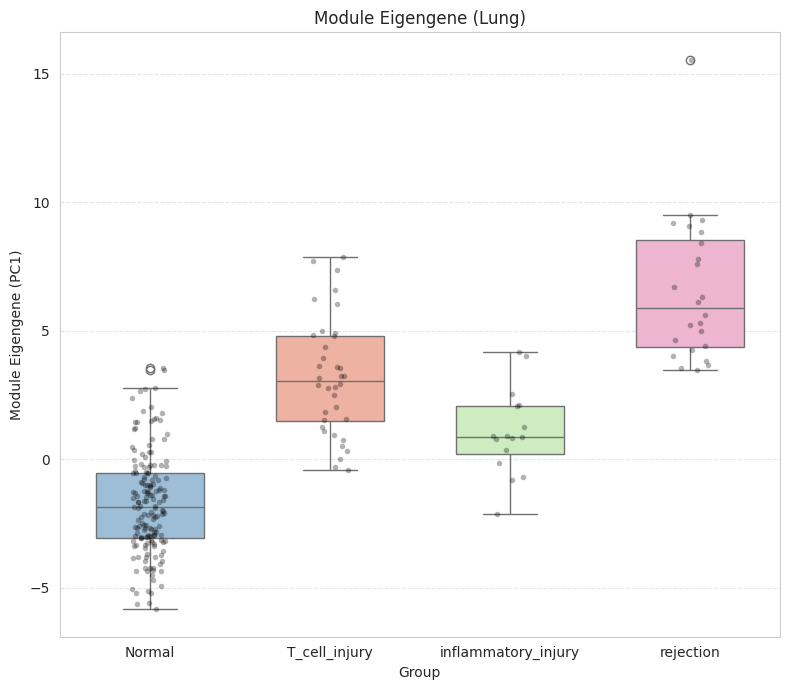

Saved barplot to: ../../figures/lung_all/20 gene biomarker/eigengene_barplot.png


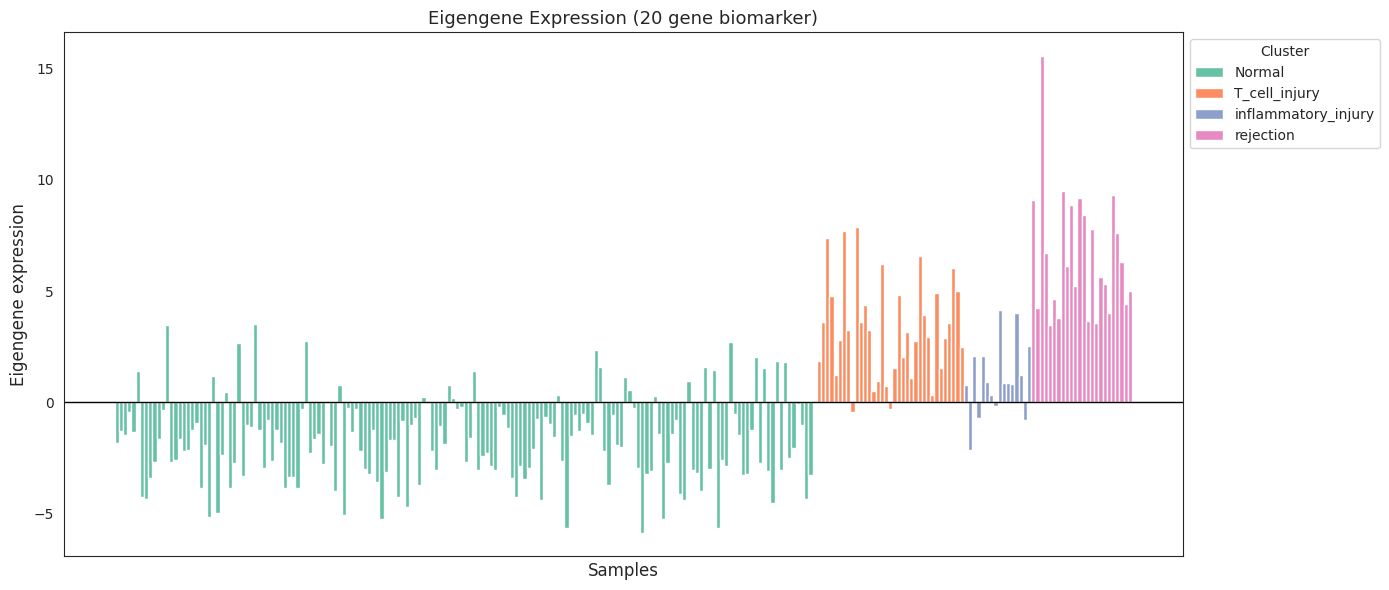

In [111]:
# 1 Heatmap
plot_module_heatmap(data_lung, meta_lung, twenty_gene_biomarker, 'lung_all', '20 gene biomarker', group_col='cluster (1, 2, 3, 4):ch1')

# 2 Compute eigengene
eigengene_lung = compute_module_eigengene(data_lung, twenty_gene_biomarker)

# 3 Welch test
module_eigengene_multi_test(eigengene_lung, meta_lung, group_col='cluster (1, 2, 3, 4):ch1')

# 4 Plot eigengene distribution
plot_eigengene_boxplot(eigengene_lung, meta_lung, 'lung_all', '20 gene biomarker', group_col='cluster (1, 2, 3, 4):ch1')

plot_multi_group_boxplot(eigengene_lung, meta_lung, 'lung_all', '20 gene biomarker', group_col='cluster (1, 2, 3, 4):ch1')


# 5 Plot eigengene bar plot
plot_eigengene_bar(eigengene_lung, meta_lung, 'lung_all', '20 gene biomarker',
                   module_name="20 gene biomarker", group_col='cluster (1, 2, 3, 4):ch1')


Saved heatmap to: ../../figures/lung/cell_cycle/heatmap.png


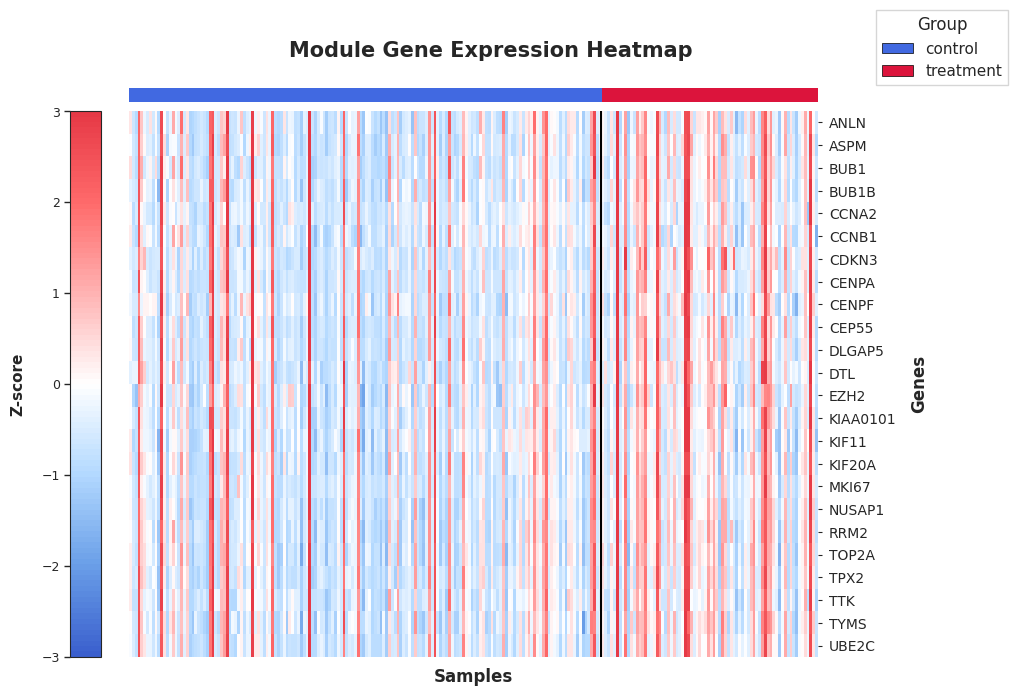

==== Welch’s t-test on Module Eigengene ====
control mean = -0.634
treatment mean = 1.385
T-statistic = -3.022
P-value = 3.012e-03


/tmp/ipykernel_2159828/561073009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)


Saved boxplot to: ../../figures/lung/cell_cycle/eigengene_boxplot.png


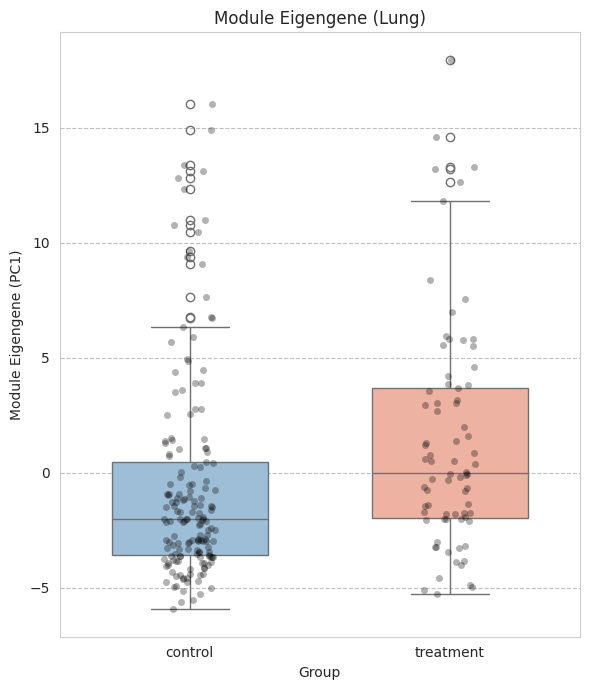

Saved barplot to: ../../figures/lung/cell_cycle/eigengene_barplot.png


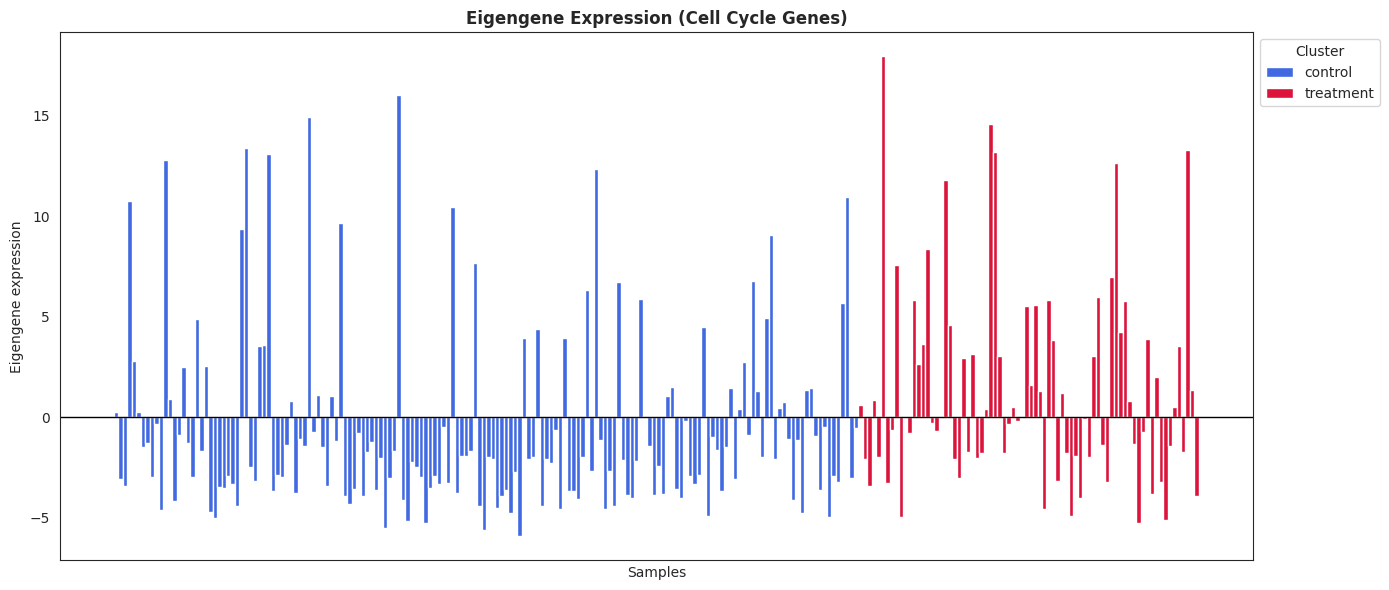

In [74]:
# 1 Heatmap
plot_module_heatmap(data_lung, meta_lung, cell_cycle_genes, 'lung', 'cell_cycle')

# 2 Compute eigengene
eigengene_lung = compute_module_eigengene(data_lung, cell_cycle_genes)

# 3 Welch test
module_eigengene_ttest(eigengene_lung, meta_lung)

# 4 Plot eigengene distribution
plot_eigengene_boxplot(eigengene_lung, meta_lung, 'lung', 'cell_cycle')

# 5 Plot eigengene bar plot
plot_eigengene_bar(eigengene_lung, meta_lung, 'lung', 'cell_cycle',
                   module_name="Cell Cycle Genes")


#### Kidney

Saved heatmap to: ../../figures/kidney/cell_cycle/heatmap.png


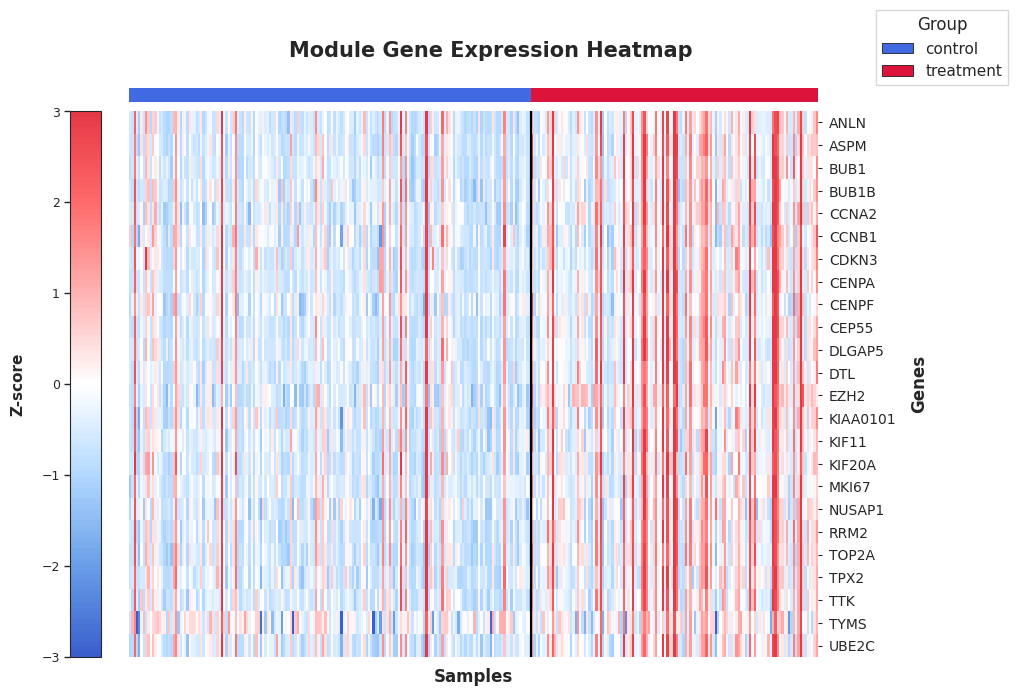

==== Welch’s t-test on Module Eigengene ====
control mean = -1.371
treatment mean = 1.919
T-statistic = -6.105
P-value = 5.592e-09


/tmp/ipykernel_2159828/561073009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)


Saved boxplot to: ../../figures/kidney/cell_cycle/eigengene_boxplot.png


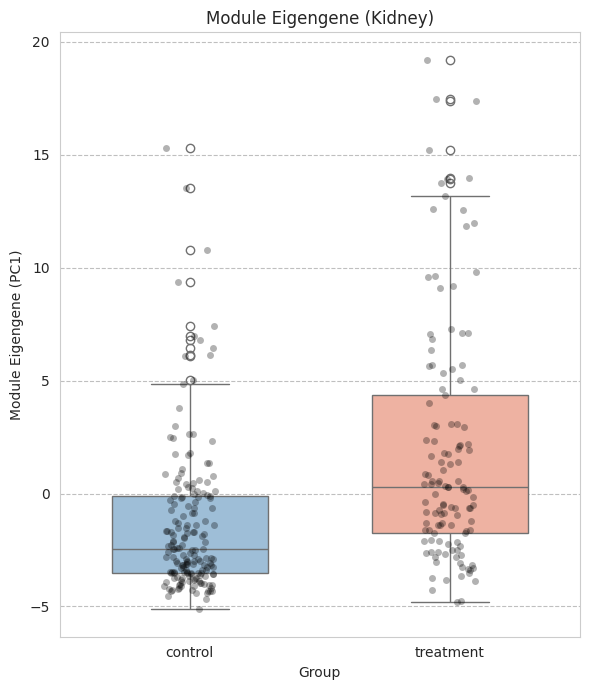

Saved barplot to: ../../figures/kidney/cell_cycle/eigengene_barplot.png


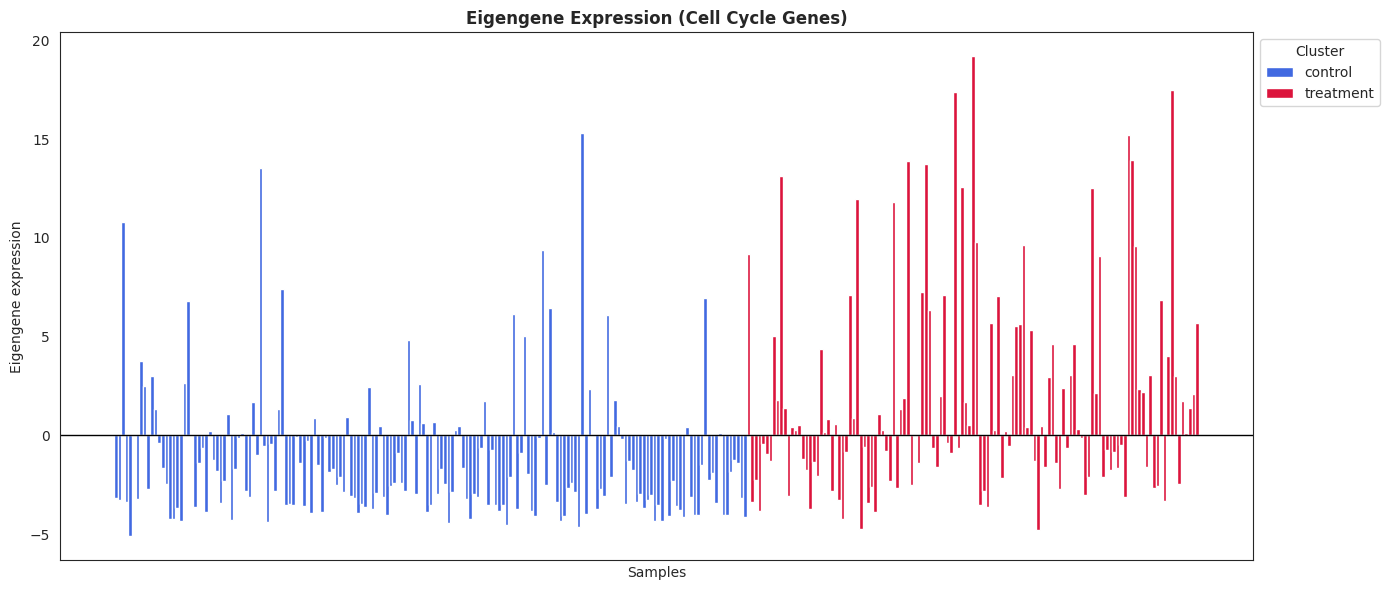

In [75]:
# 1 Heatmap
plot_module_heatmap(data_kidney, meta_kidney, cell_cycle_genes, 'kidney', 'cell_cycle')

# 2 Compute eigengene
eigengene_kidney = compute_module_eigengene(data_kidney, cell_cycle_genes)

# 3 Welch test
module_eigengene_ttest(eigengene_kidney, meta_kidney)

# 4 Plot eigengene distribution
plot_eigengene_boxplot(eigengene_kidney, meta_kidney, 'kidney', 'cell_cycle')

# 5 Plot eigengene bar plot
plot_eigengene_bar(eigengene_kidney, meta_kidney, 'kidney', 'cell_cycle',
                   module_name="Cell Cycle Genes")


Saved heatmap to: ../../figures/kidney/20 gene biomarker/heatmap.png


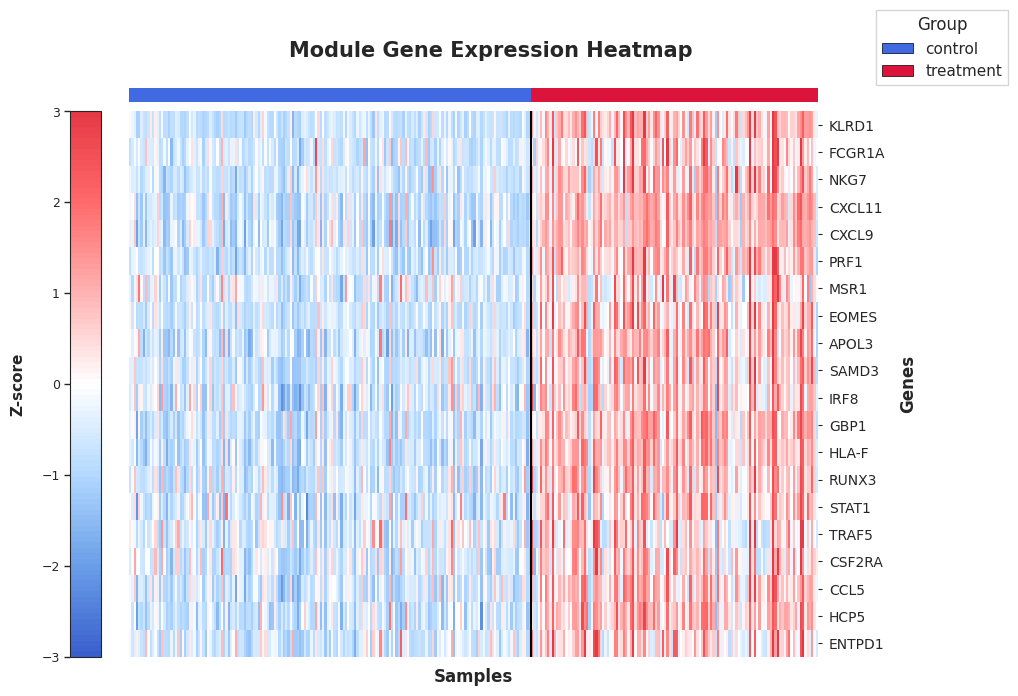

==== Welch’s t-test on Module Eigengene ====
control mean = -2.437
treatment mean = 3.412
T-statistic = -17.635
P-value = 1.552e-41


/tmp/ipykernel_2159828/561073009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)


Saved boxplot to: ../../figures/kidney/20 gene biomarker/eigengene_boxplot.png


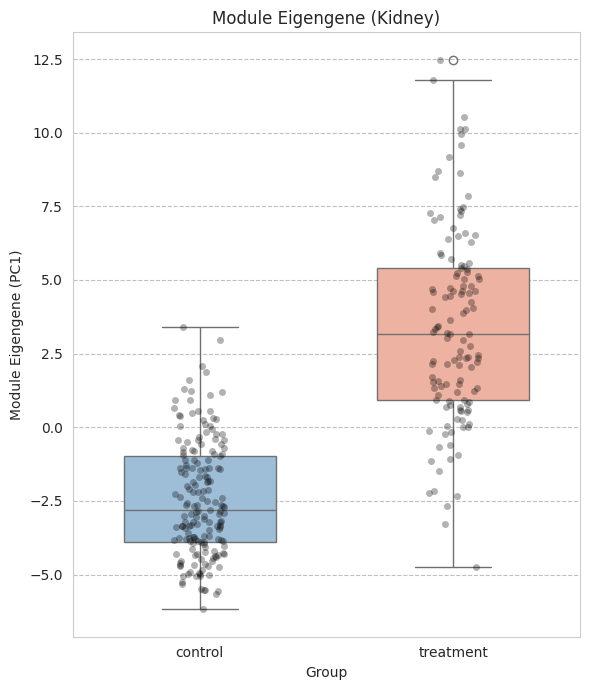

Saved barplot to: ../../figures/kidney/20 gene biomarker/eigengene_barplot.png


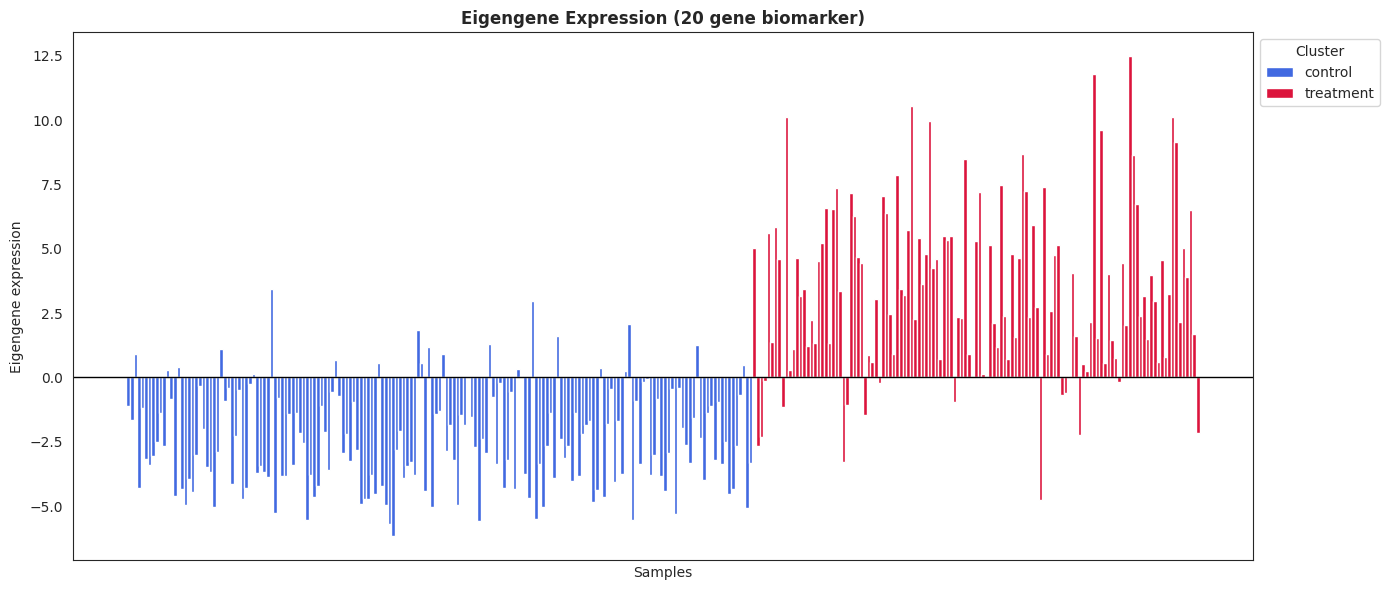

In [76]:
# 1 Heatmap
plot_module_heatmap(data_kidney, meta_kidney, twenty_gene_biomarker, 'kidney', '20 gene biomarker')

# 2 Compute eigengene
eigengene_kidney = compute_module_eigengene(data_kidney, twenty_gene_biomarker)

# 3 Welch test
module_eigengene_ttest(eigengene_kidney, meta_kidney)

# 4 Plot eigengene distribution
plot_eigengene_boxplot(eigengene_kidney, meta_kidney, 'kidney', '20 gene biomarker')

# 5 Plot eigengene bar plot
plot_eigengene_bar(eigengene_kidney, meta_kidney, 'kidney', '20 gene biomarker',
                   module_name="20 gene biomarker")


Saved heatmap to: ../../figures/kidney/6 gene biomarker/heatmap.png


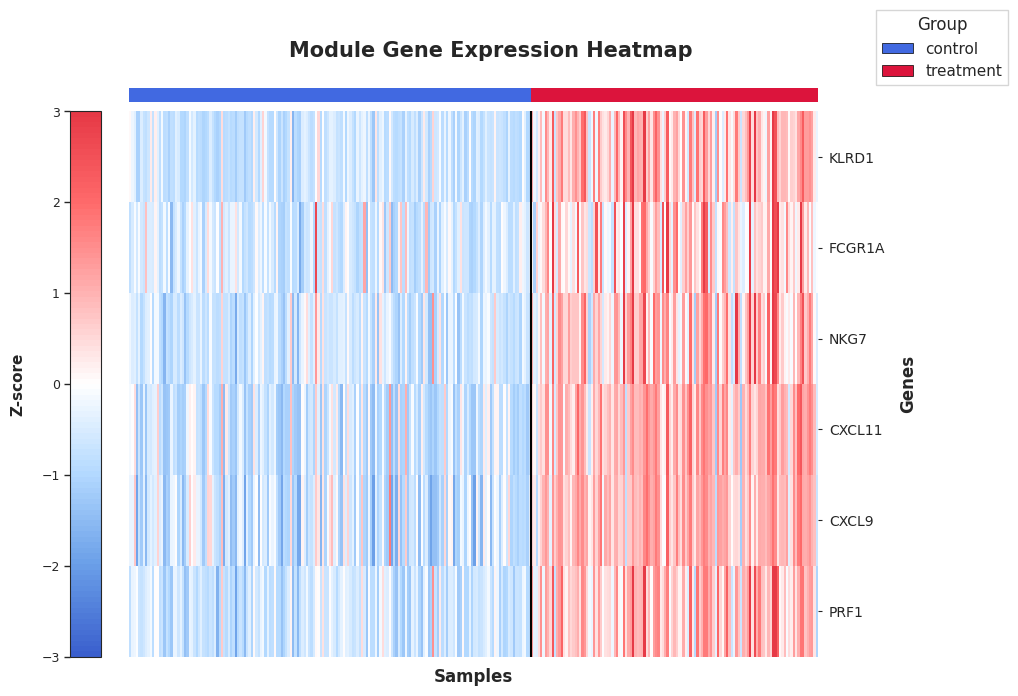

==== Welch’s t-test on Module Eigengene ====
control mean = -1.469
treatment mean = 2.057
T-statistic = -19.978
P-value = 6.885e-48


/tmp/ipykernel_2159828/561073009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)


Saved boxplot to: ../../figures/kidney/6 gene biomarker/eigengene_boxplot.png


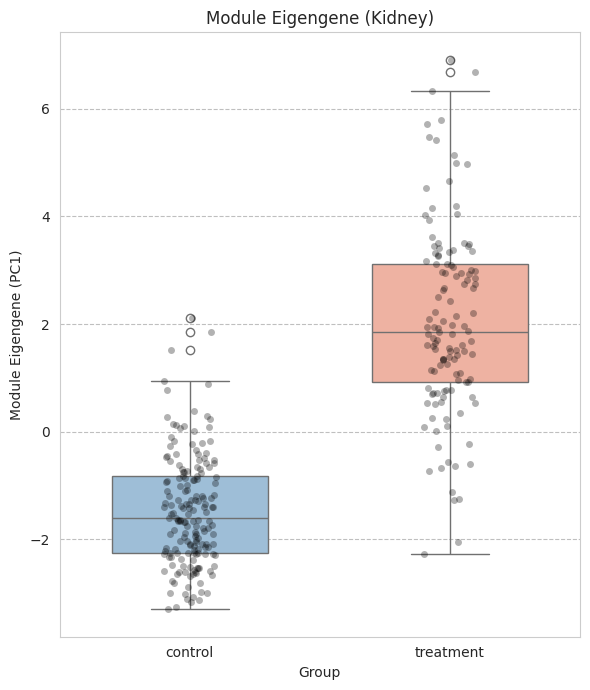

Saved barplot to: ../../figures/kidney/6 gene biomarker/eigengene_barplot.png


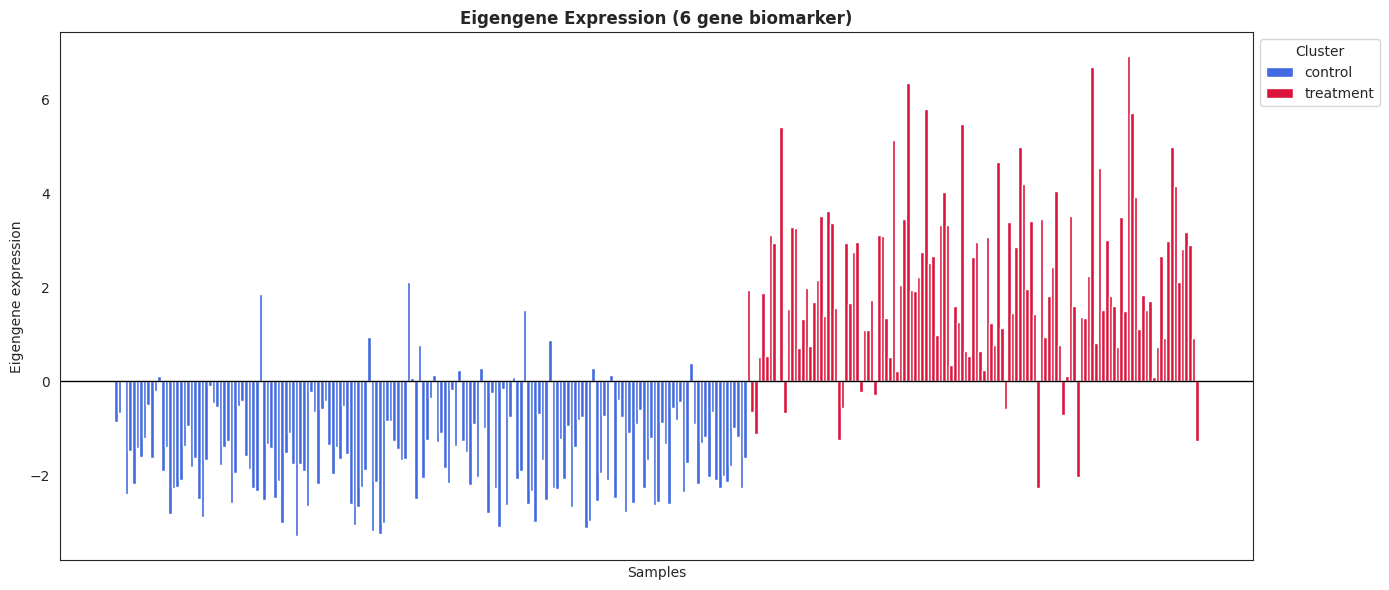

In [77]:
# 1 Heatmap
plot_module_heatmap(data_kidney, meta_kidney, six_gene_biomarker, 'kidney', '6 gene biomarker')

# 2 Compute eigengene
eigengene_kidney = compute_module_eigengene(data_kidney, six_gene_biomarker)

# 3 Welch test
module_eigengene_ttest(eigengene_kidney, meta_kidney)

# 4 Plot eigengene distribution
plot_eigengene_boxplot(eigengene_kidney, meta_kidney, 'kidney', '6 gene biomarker')

# 5 Plot eigengene bar plot
plot_eigengene_bar(eigengene_kidney, meta_kidney, 'kidney', '6 gene biomarker',
                   module_name="6 gene biomarker")


#### Heart

Saved heatmap to: ../../figures/heart/cell_cycle/heatmap.png


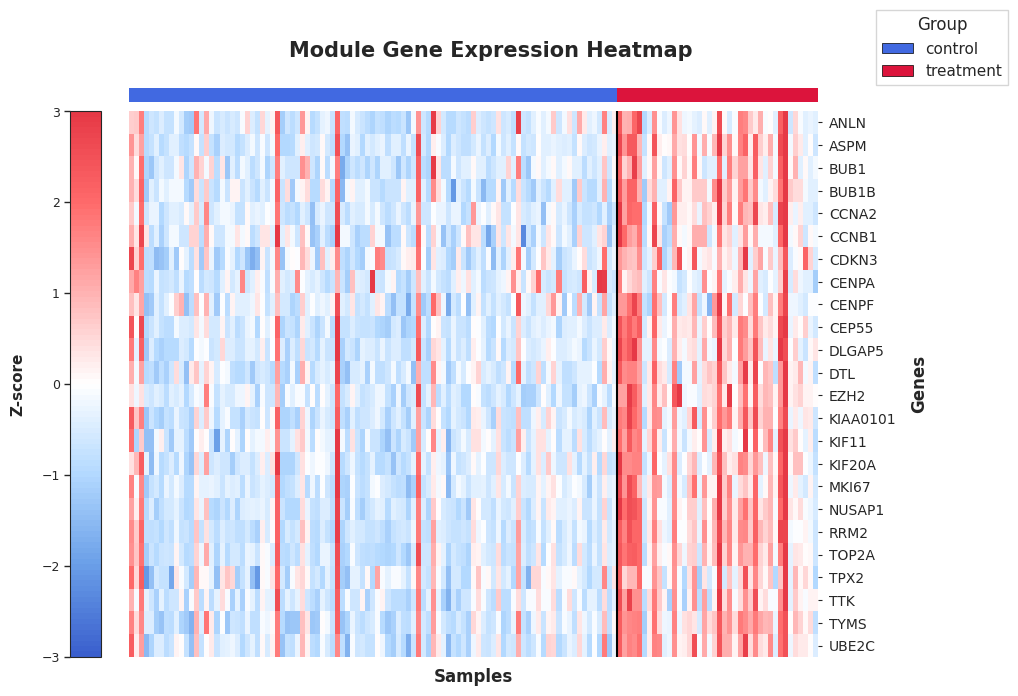

==== Welch’s t-test on Module Eigengene ====
control mean = -1.493
treatment mean = 3.620
T-statistic = -6.361
P-value = 4.179e-08


/tmp/ipykernel_2159828/561073009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)


Saved boxplot to: ../../figures/heart/cell_cycle/eigengene_boxplot.png


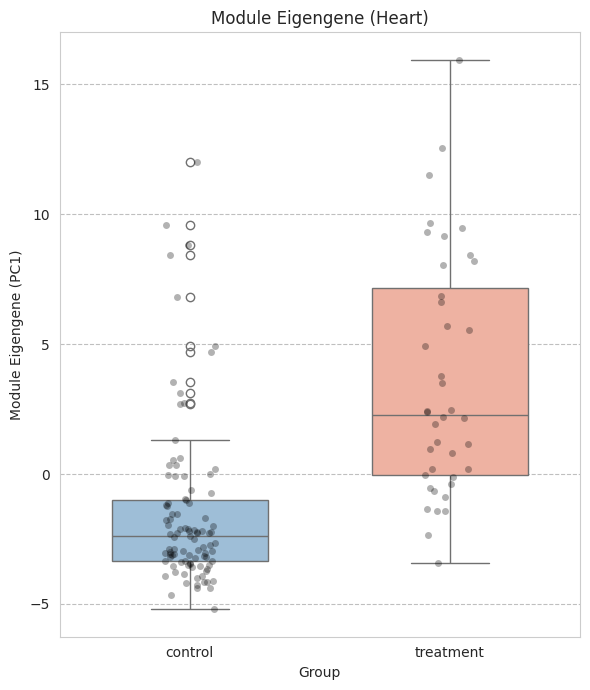

Saved barplot to: ../../figures/heart/cell_cycle/eigengene_barplot.png


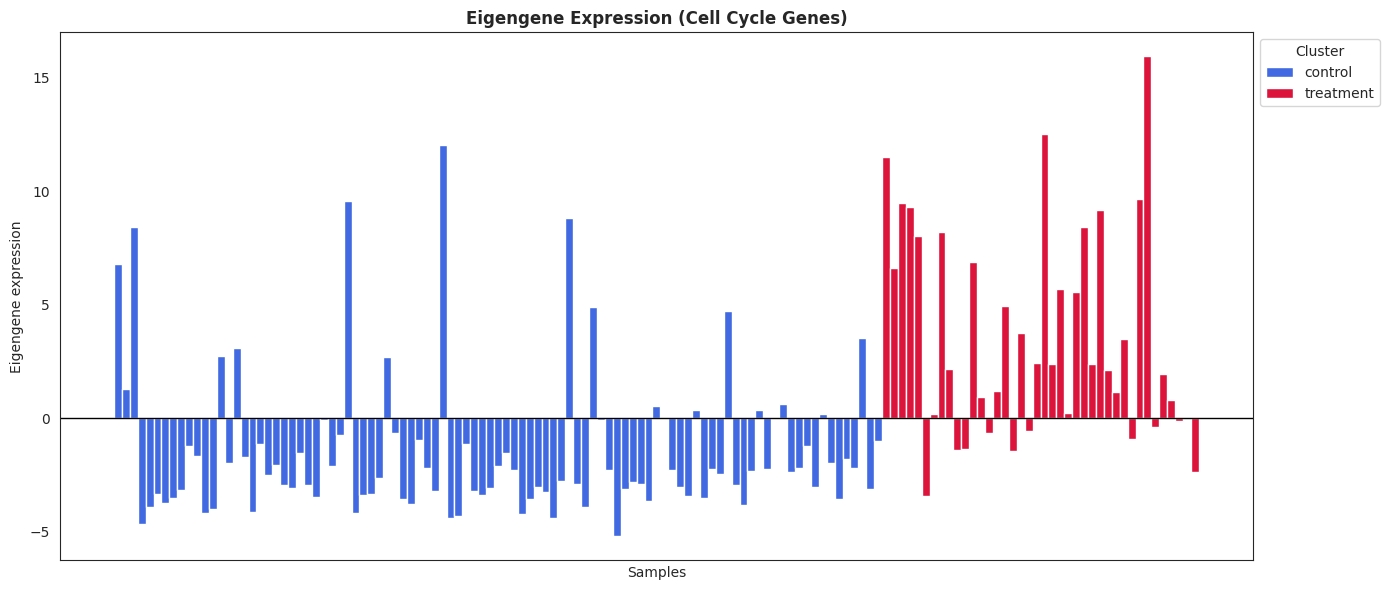

In [78]:
# 1 Heatmap
plot_module_heatmap(data_heart, meta_heart, cell_cycle_genes, 'heart', 'cell_cycle')

# 2 Compute eigengene
eigengene_heart = compute_module_eigengene(data_heart, cell_cycle_genes)

# 3 Welch test
module_eigengene_ttest(eigengene_heart, meta_heart)

# 4 Plot eigengene distribution
plot_eigengene_boxplot(eigengene_heart, meta_heart, 'heart', 'cell_cycle')

# 5 Plot eigengene bar plot
plot_eigengene_bar(eigengene_heart, meta_heart, 'heart', 'cell_cycle',
                   module_name="Cell Cycle Genes")


Saved heatmap to: ../../figures/heart/20 gene biomarker/heatmap.png


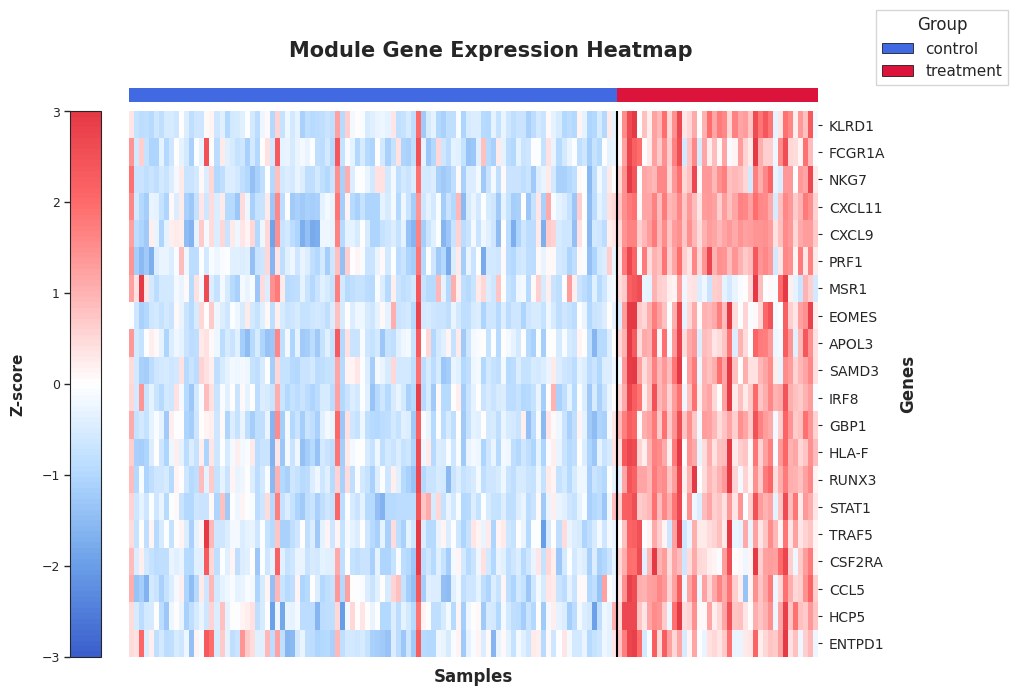

==== Welch’s t-test on Module Eigengene ====
control mean = -1.942
treatment mean = 4.709
T-statistic = -12.965
P-value = 4.225e-19


/tmp/ipykernel_2159828/561073009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)


Saved boxplot to: ../../figures/heart/20 gene biomarker/eigengene_boxplot.png


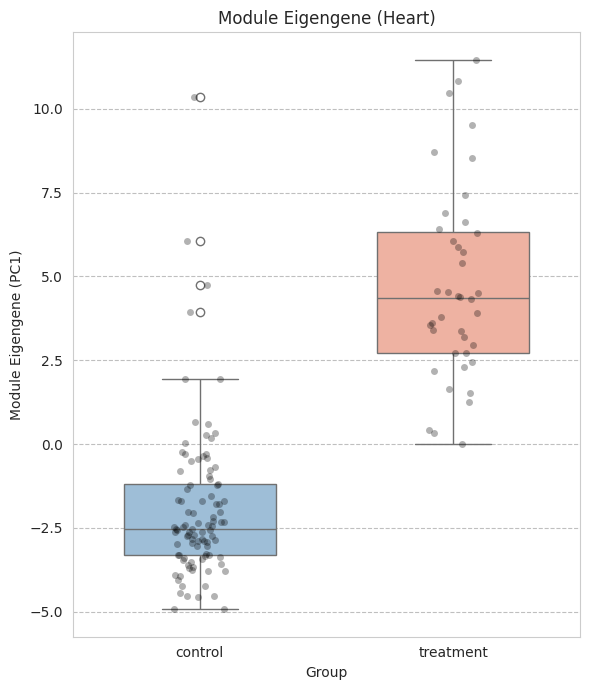

Saved barplot to: ../../figures/heart/20 gene biomarker/eigengene_barplot.png


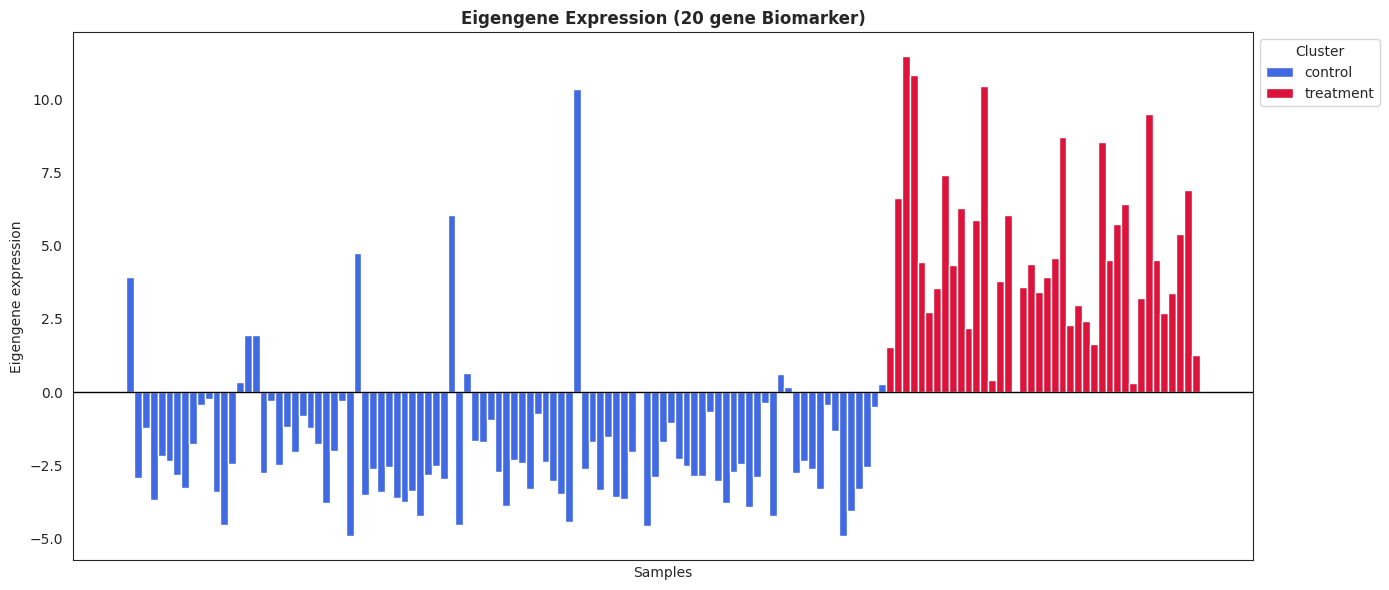

In [79]:
# 1 Heatmap
plot_module_heatmap(data_heart, meta_heart, twenty_gene_biomarker, 'heart', '20 gene biomarker')

# 2 Compute eigengene
eigengene_heart = compute_module_eigengene(data_heart, twenty_gene_biomarker)

# 3 Welch test
module_eigengene_ttest(eigengene_heart, meta_heart)

# 4 Plot eigengene distribution
plot_eigengene_boxplot(eigengene_heart, meta_heart, 'heart', '20 gene biomarker')

# 5 Plot eigengene bar plot
plot_eigengene_bar(eigengene_heart, meta_heart, 'heart', '20 gene biomarker',
                   module_name="20 gene Biomarker")


Saved heatmap to: ../../figures/heart/6 gene biomarker/heatmap.png


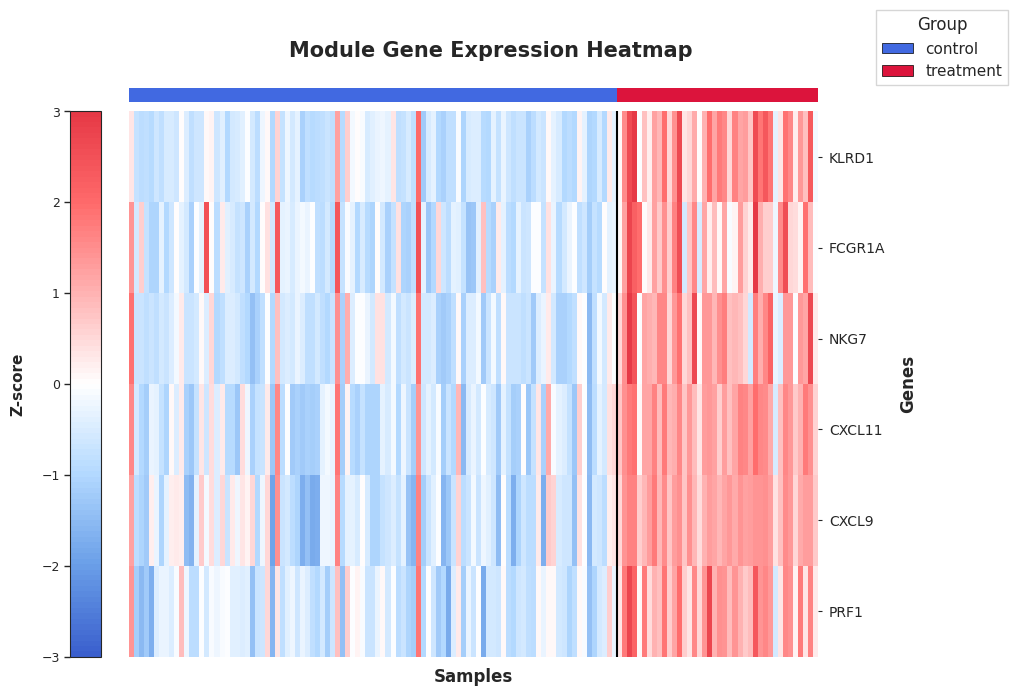

==== Welch’s t-test on Module Eigengene ====
control mean = -1.135
treatment mean = 2.752
T-statistic = -14.528
P-value = 1.400e-22


/tmp/ipykernel_2159828/561073009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)


Saved boxplot to: ../../figures/heart/6 gene biomarker/eigengene_boxplot.png


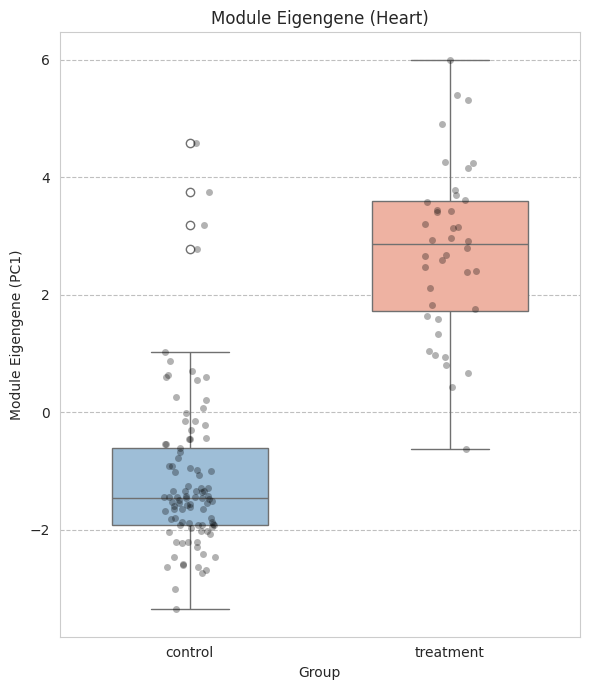

Saved barplot to: ../../figures/heart/6 gene biomarker/eigengene_barplot.png


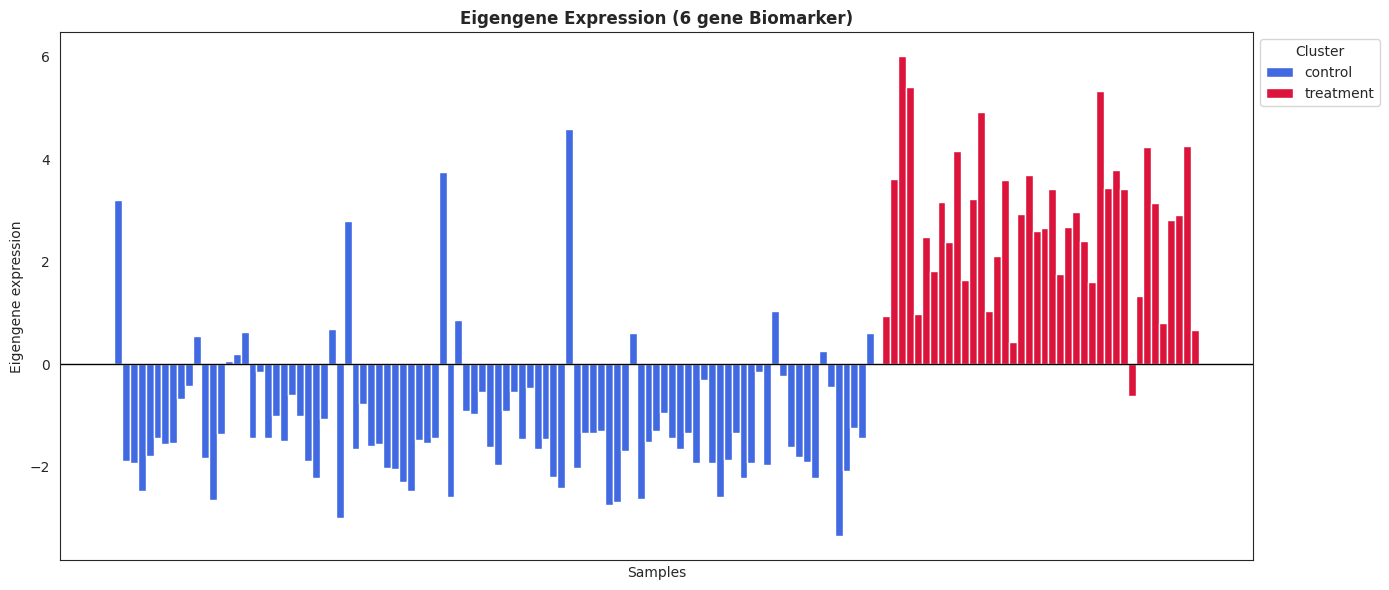

In [80]:
# 1 Heatmap
plot_module_heatmap(data_heart, meta_heart, six_gene_biomarker, 'heart', '6 gene biomarker')

# 2 Compute eigengene
eigengene_heart = compute_module_eigengene(data_heart, six_gene_biomarker)

# 3 Welch test
module_eigengene_ttest(eigengene_heart, meta_heart)

# 4 Plot eigengene distribution
plot_eigengene_boxplot(eigengene_heart, meta_heart, 'heart', '6 gene biomarker')

# 5 Plot eigengene bar plot
plot_eigengene_bar(eigengene_heart, meta_heart, 'heart', '6 gene biomarker',
                   module_name="6 gene Biomarker")


#### Liver

In [81]:
meta_liver['classes'] = meta_liver['classes'].replace({
    0: 'treatment',
    1: 'control',
})

In [82]:
meta_liver['classes'].value_counts()

classes
control      129
treatment    106
Name: count, dtype: int64

Saved heatmap to: ../../figures/liver/cell_cycle/heatmap.png


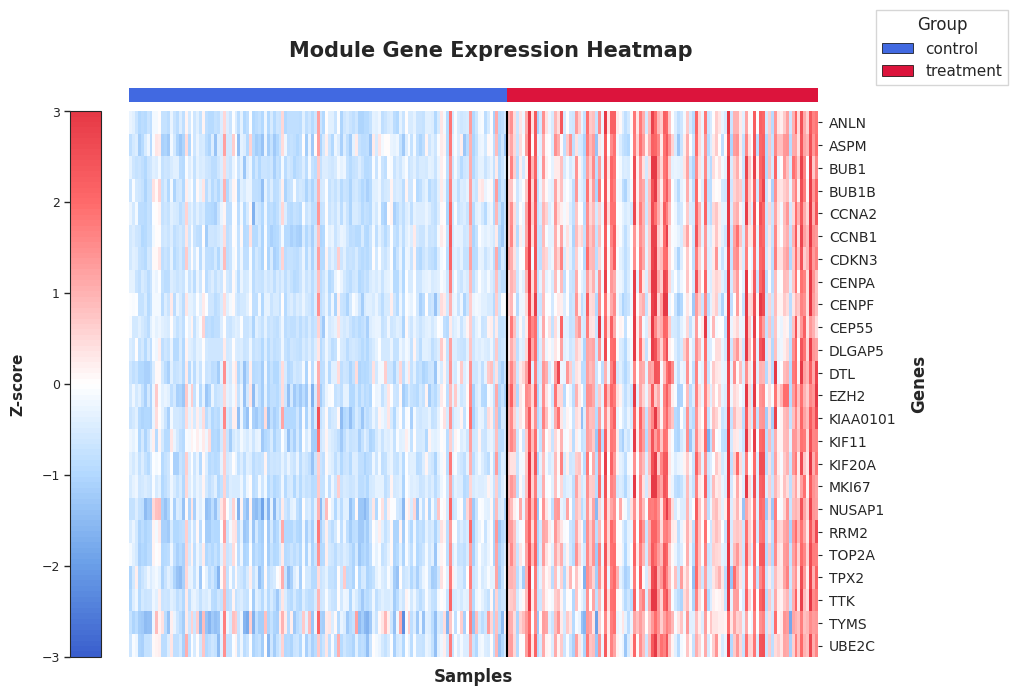

==== Welch’s t-test on Module Eigengene ====
control mean = -2.401
treatment mean = 2.922
T-statistic = -10.090
P-value = 2.960e-18


/tmp/ipykernel_2159828/561073009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)


Saved boxplot to: ../../figures/liver/cell_cycle/eigengene_boxplot.png


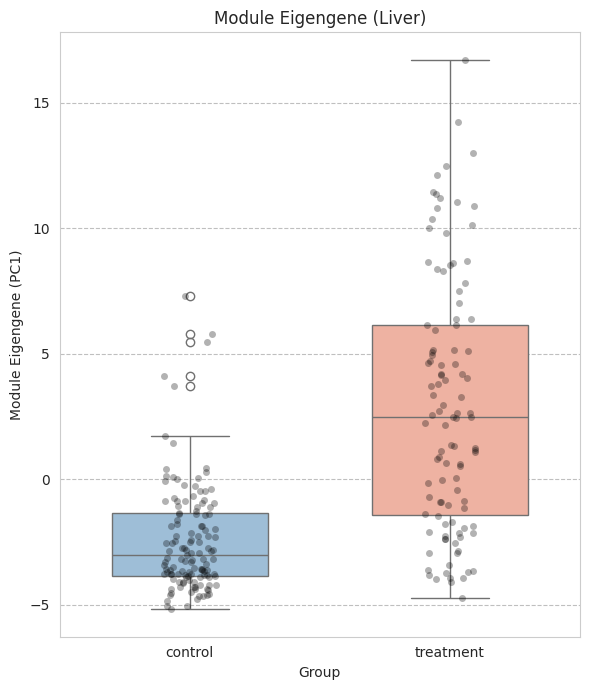

Saved barplot to: ../../figures/liver/cell_cycle/eigengene_barplot.png


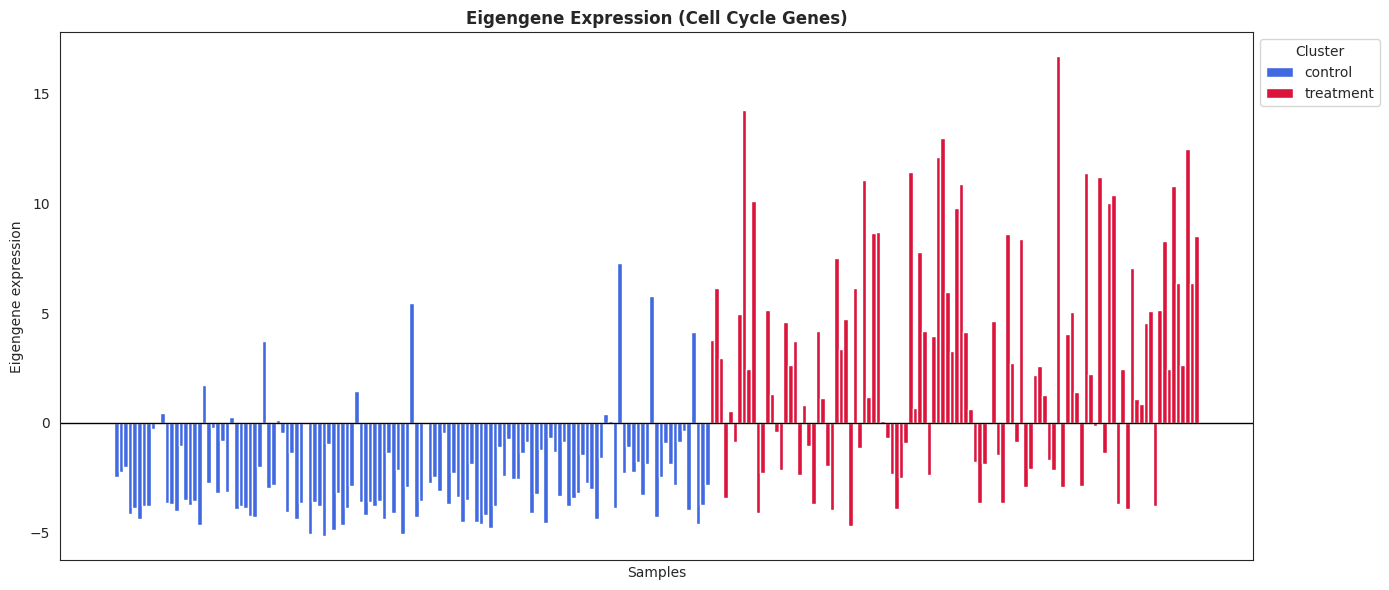

In [83]:
# 1 Heatmap
plot_module_heatmap(data_liver, meta_liver, cell_cycle_genes, 'liver', 'cell_cycle', group_col='classes')

# 2 Compute eigengene
eigengene_liver = compute_module_eigengene(data_liver, cell_cycle_genes)

# 3 Welch test
module_eigengene_ttest(eigengene_liver, meta_liver, group_col='classes')

# 4 Plot eigengene distribution
plot_eigengene_boxplot(eigengene_liver, meta_liver, 'liver', 'cell_cycle', group_col='classes')

# 5 Plot eigengene bar plot
plot_eigengene_bar(eigengene_liver, meta_liver, 'liver', 'cell_cycle',
                   module_name="Cell Cycle Genes", group_col='classes')


Saved heatmap to: ../../figures/liver/20 gene biomarker/heatmap.png


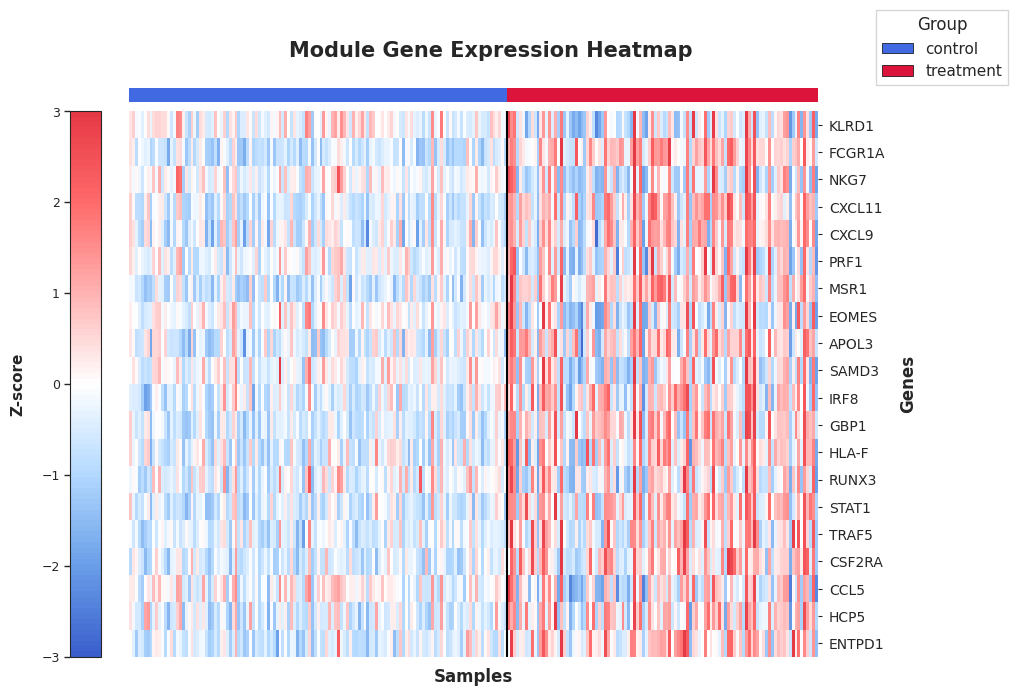

==== Welch’s t-test on Module Eigengene ====
control mean = -1.237
treatment mean = 1.505
T-statistic = -5.976
P-value = 1.685e-08


/tmp/ipykernel_2159828/561073009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)


Saved boxplot to: ../../figures/liver/20 gene biomarker/eigengene_boxplot.png


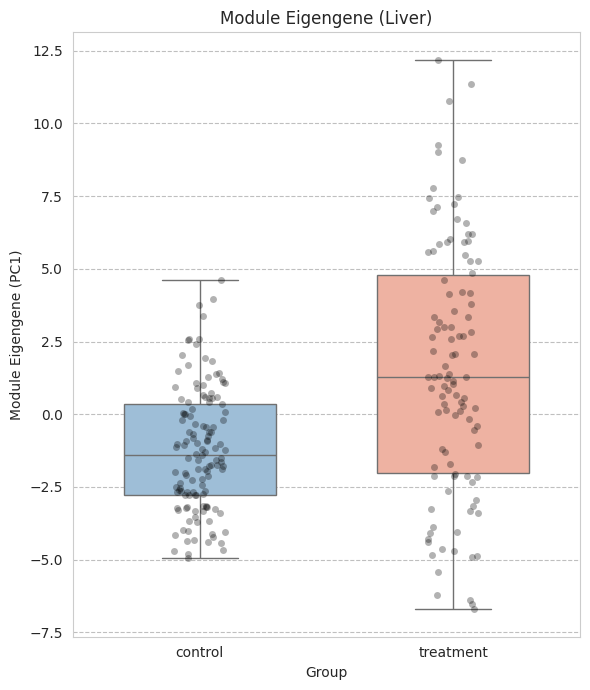

Saved barplot to: ../../figures/liver/20 gene biomarker/eigengene_barplot.png


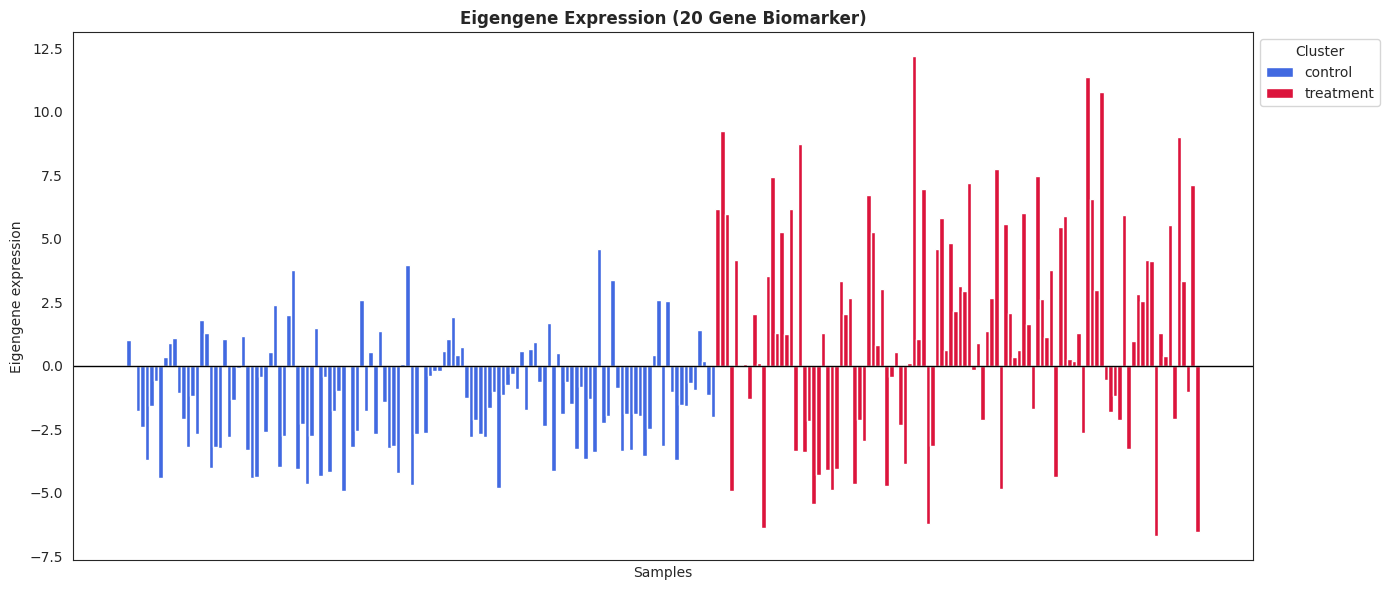

In [84]:
# 1 Heatmap
plot_module_heatmap(data_liver, meta_liver, twenty_gene_biomarker, 'liver', '20 gene biomarker', group_col='classes')

# 2 Compute eigengene
eigengene_liver = compute_module_eigengene(data_liver, twenty_gene_biomarker)

# 3 Welch test
module_eigengene_ttest(eigengene_liver, meta_liver, group_col='classes')

# 4 Plot eigengene distribution
plot_eigengene_boxplot(eigengene_liver, meta_liver, 'liver', '20 gene biomarker', group_col='classes')

# 5 Plot eigengene bar plot
plot_eigengene_bar(eigengene_liver, meta_liver, 'liver', '20 gene biomarker',
                   module_name="20 Gene Biomarker", group_col='classes')


Saved heatmap to: ../../figures/liver/6 gene biomarker/heatmap.png


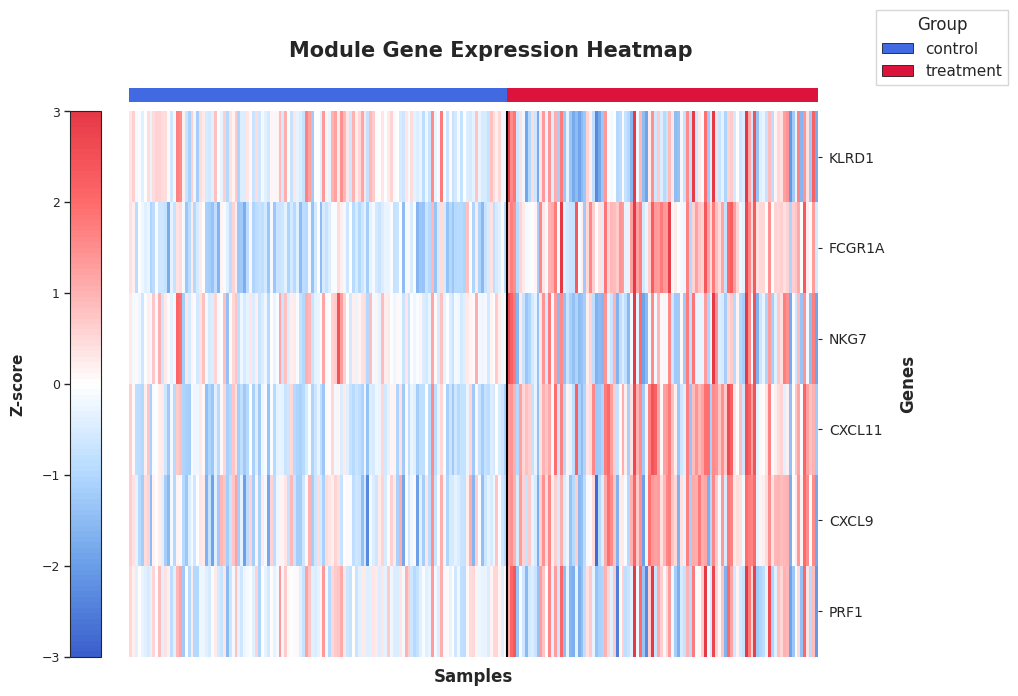

==== Welch’s t-test on Module Eigengene ====
control mean = -0.535
treatment mean = 0.651
T-statistic = -4.270
P-value = 3.560e-05


/tmp/ipykernel_2159828/561073009.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Group", y="Eigengene", palette=muted_palette, width=0.6)


Saved boxplot to: ../../figures/liver/6 gene biomarker/eigengene_boxplot.png


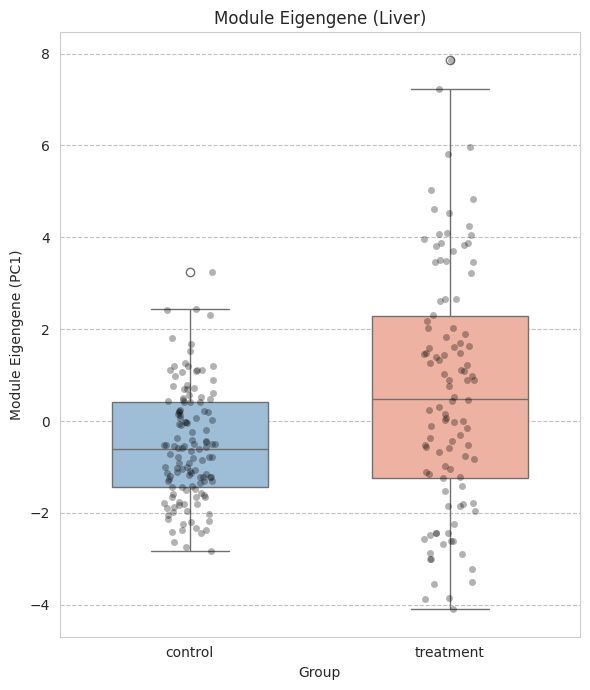

Saved barplot to: ../../figures/liver/6 gene biomarker/eigengene_barplot.png


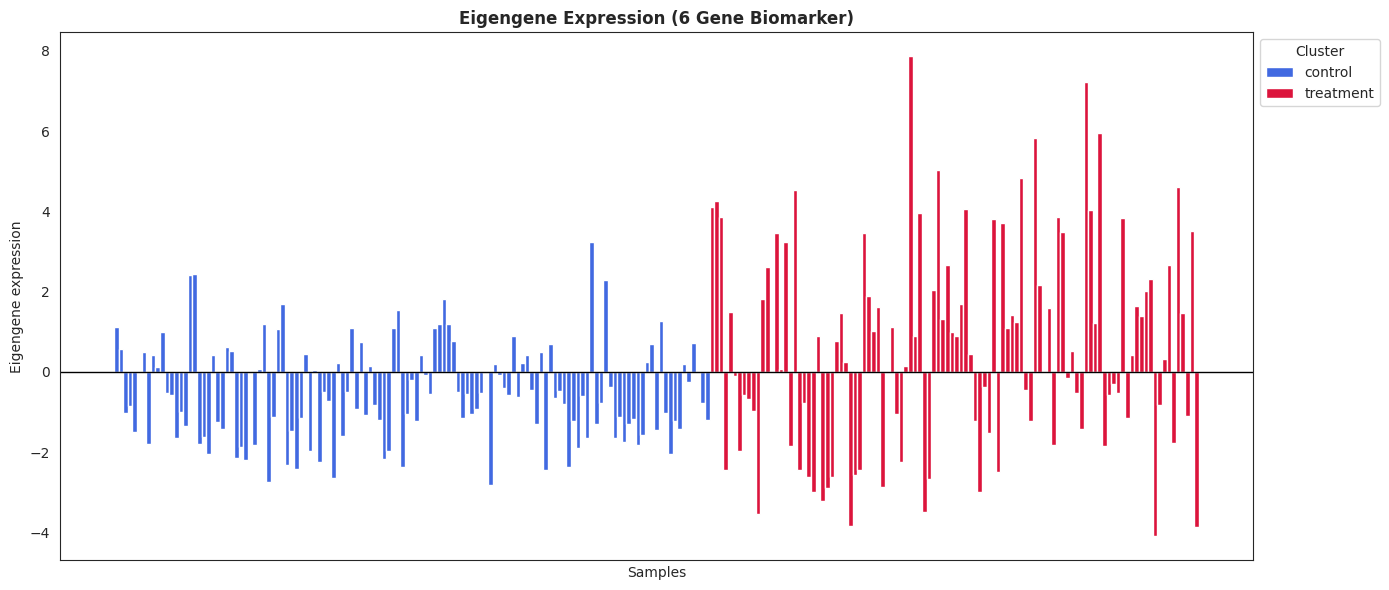

In [85]:
# 1 Heatmap
plot_module_heatmap(data_liver, meta_liver, six_gene_biomarker, 'liver', '6 gene biomarker', group_col='classes')

# 2 Compute eigengene
eigengene_liver = compute_module_eigengene(data_liver, six_gene_biomarker)

# 3 Welch test
module_eigengene_ttest(eigengene_liver, meta_liver, group_col='classes')

# 4 Plot eigengene distribution
plot_eigengene_boxplot(eigengene_liver, meta_liver, 'liver', '6 gene biomarker', group_col='classes')

# 5 Plot eigengene bar plot
plot_eigengene_bar(eigengene_liver, meta_liver, 'liver', '6 gene biomarker',
                   module_name="6 Gene Biomarker", group_col='classes')
